<a href="https://colab.research.google.com/github/ericyoc/ai_universe_coding/blob/main/AI_Universe_Coding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Universe Coding - A Complete Guide
### From Neural Networks to Generative AI

This notebook mirrors **every topic** from *The AI Universe* diagram, organized into six progressive modules.  
Each module contains a **concept explanation**, **working code demo**, and **table / chart output**.

| Module | Ring | Key Topics |
|--------|------|------------|
| 0 | Setup | Google Drive, libraries, overview diagram |
| 1 | Artificial Intelligence | Planning, NLP, Computer Vision, Expert Systems |
| 2 | Machine Learning | Supervised, Unsupervised, Decision Trees, SVM, Ensemble |
| 3 | Neural Networks | Perceptrons, MLP, CNN, LSTM, RNN, Backprop |
| 4 | Deep Learning | DNNs, Transfer Learning, GANs, Attention, RL |
| 5 | Generative AI | Transformers, Language Models, Summarization, Dialogue |

> **How to use:** Run cells top-to-bottom. Each section is self-contained.  
> GPU Runtime recommended: *Runtime → Change runtime type → T4 GPU*


---
## Module 0 - Setup & Environment
### 0.1 Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
SAVE_DIR = '/content/drive/MyDrive/AI_Universe_Course'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✅ Drive mounted. Files will save to: {SAVE_DIR}")

Mounted at /content/drive
✅ Drive mounted. Files will save to: /content/drive/MyDrive/AI_Universe_Course


### 0.2 Install & Import All Required Libraries

In [2]:
# ── Core scientific stack ──────────────────────────────────────────────────
import subprocess, sys
packages = [
    "transformers", "datasets", "sentencepiece",
    "scikit-learn", "seaborn", "plotly", "wordcloud",
    "minisom",          # Self-Organizing Maps
    "gymnasium",        # Reinforcement Learning environments
]
for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

# ── Standard imports ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
import warnings, random, math, time
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

# ── Machine Learning ────────────────────────────────────────────────────────
from sklearn.datasets import (load_iris, load_breast_cancer, load_digits,
                               make_classification, make_moons, make_blobs)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, mean_squared_error)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, VotingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.pipeline import Pipeline

# ── Deep Learning ───────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import mnist, cifar10, imdb
from tensorflow.keras.utils import to_categorical
print(f"✅ TensorFlow {tf.__version__} | NumPy {np.__version__}")
print(f"✅ GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ TensorFlow 2.20.0 | NumPy 2.0.2
✅ GPU available: True


### 0.3 AI Universe - Concentric Rings Overview Diagram

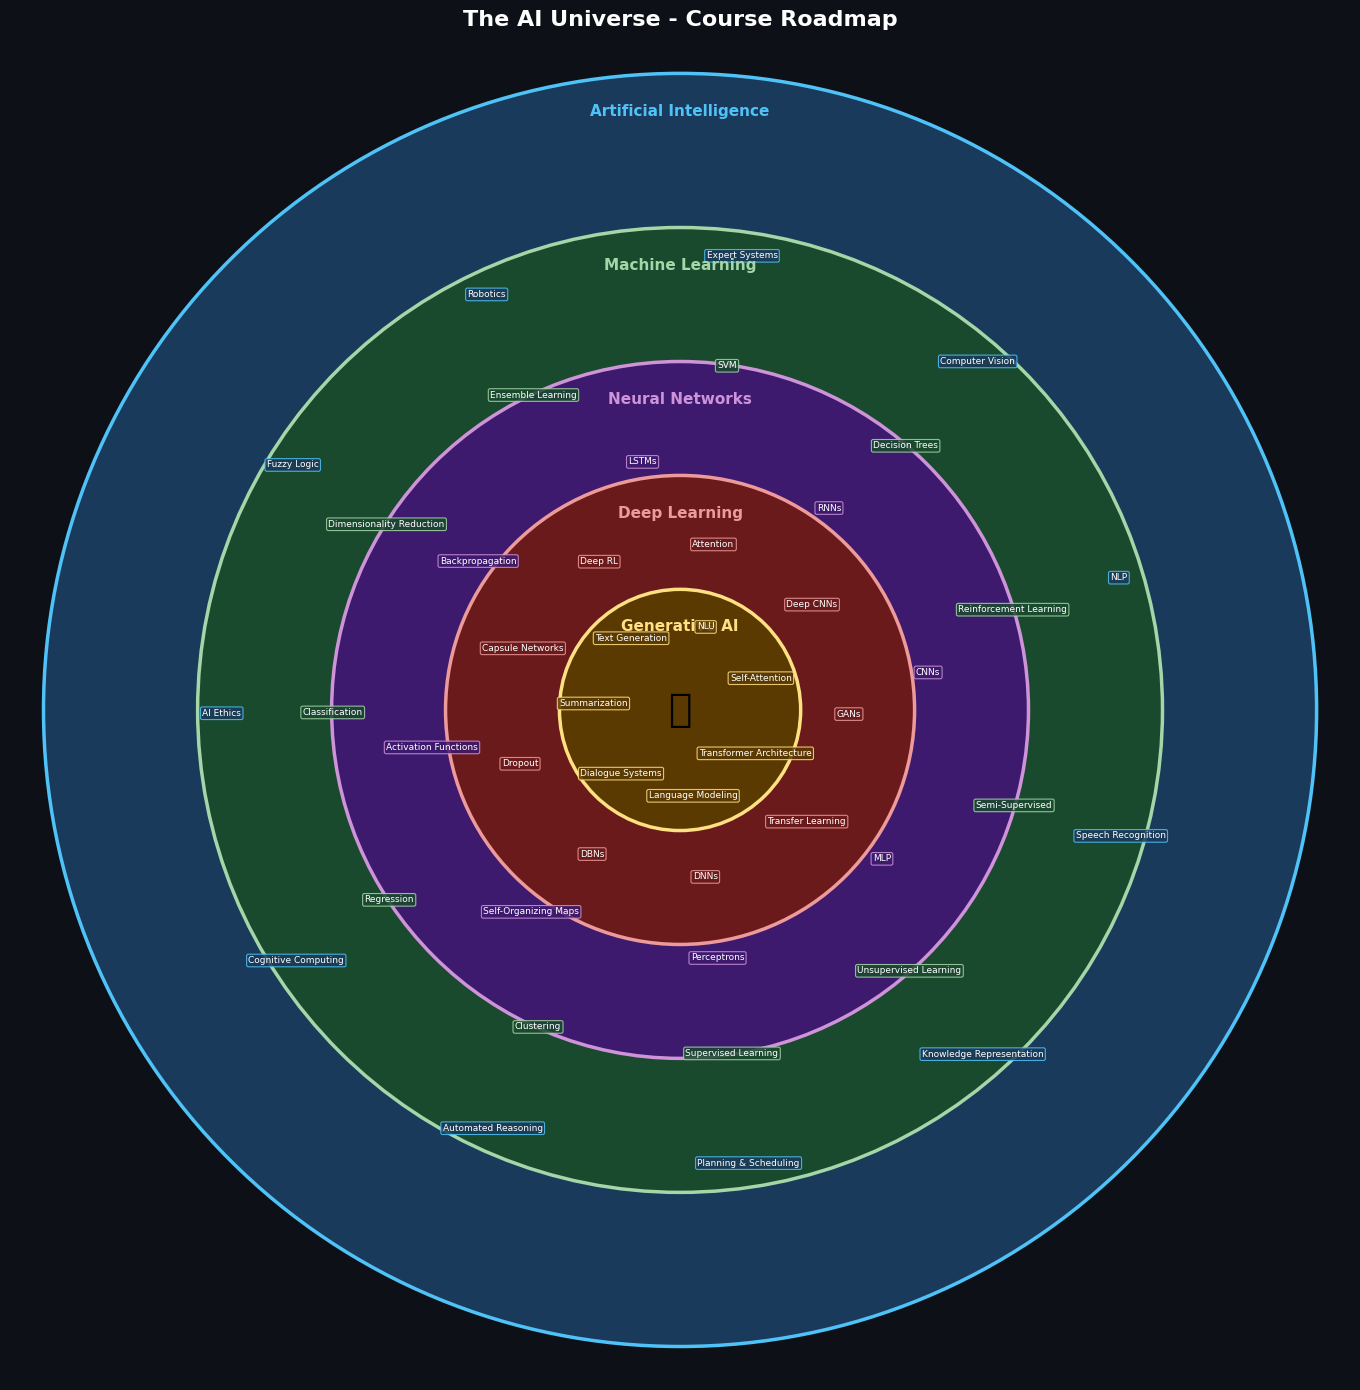

✅ Overview diagram saved.


In [3]:
fig, ax = plt.subplots(figsize=(14, 14))
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect('equal'); ax.axis('off')
ax.set_facecolor('#0d1117'); fig.patch.set_facecolor('#0d1117')

rings = [
    (0.95, '#1a3a5c', 'Artificial Intelligence',   '#4fc3f7',
     ['Planning & Scheduling','Knowledge Representation','Speech Recognition',
      'NLP','Computer Vision','Expert Systems','Robotics','Fuzzy Logic',
      'AI Ethics','Cognitive Computing','Automated Reasoning']),
    (0.72, '#1a4a2e', 'Machine Learning',           '#a5d6a7',
     ['Supervised Learning','Unsupervised Learning','Semi-Supervised',
      'Reinforcement Learning','Decision Trees','SVM','Ensemble Learning',
      'Dimensionality Reduction','Classification','Regression','Clustering']),
    (0.52, '#3d1a6e', 'Neural Networks',            '#ce93d8',
     ['Perceptrons','MLP','CNNs','RNNs','LSTMs','Backpropagation',
      'Activation Functions','Self-Organizing Maps']),
    (0.35, '#6a1a1a', 'Deep Learning',              '#ef9a9a',
     ['DNNs','Transfer Learning','GANs','Deep CNNs','Attention',
      'Deep RL','Capsule Networks','Dropout','DBNs']),
    (0.18, '#5a3a00', 'Generative AI',              '#ffe082',
     ['Language Modeling','Transformer Architecture','Self-Attention',
      'NLU','Text Generation','Summarization','Dialogue Systems']),
]

for radius, facecolor, label, textcolor, topics in rings:
    circle = plt.Circle((0, 0), radius, color=facecolor, zorder=1)
    ax.add_patch(circle)
    border = plt.Circle((0, 0), radius, color=textcolor, fill=False, lw=2.5, zorder=2)
    ax.add_patch(border)
    ax.text(0, radius - 0.045, label, ha='center', va='top',
            fontsize=11, fontweight='bold', color=textcolor, zorder=5)
    n = len(topics)
    for i, topic in enumerate(topics):
        angle = 2 * math.pi * i / n - math.pi / 2 + 0.15
        r = radius * 0.72
        x = r * math.cos(angle); y = r * math.sin(angle)
        ax.text(x, y, topic, ha='center', va='center',
                fontsize=6.5, color='white', zorder=5,
                bbox=dict(boxstyle='round,pad=0.2', fc=facecolor, ec=textcolor, lw=0.8, alpha=0.85))

ax.text(0, 0, '🤖', ha='center', va='center', fontsize=28, zorder=6)
ax.set_title('The AI Universe - Course Roadmap', color='white',
             fontsize=16, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/00_ai_universe_overview.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("✅ Overview diagram saved.")

---
## Module 1 - Artificial Intelligence (Outer Ring)

**Artificial Intelligence** is the broadest category - any technique that enables machines to simulate human-like reasoning, perception, or decision-making.

| Sub-field | Description |
|-----------|-------------|
| Planning & Scheduling | Finding sequences of actions to achieve a goal (BFS, A*, STRIPS) |
| Knowledge Representation | Encoding facts and rules machines can reason over |
| NLP | Understanding and generating human language |
| Computer Vision | Interpreting images and video |
| Expert Systems | Rule-based systems that mimic domain experts |
| Speech Recognition | Converting spoken audio to text |
| Robotics | Autonomous physical agents |
| Fuzzy Logic | Handling imprecision and partial truth |
| AI Ethics | Fairness, accountability, transparency |


### 1.1 Planning & Scheduling - BFS and A* Search

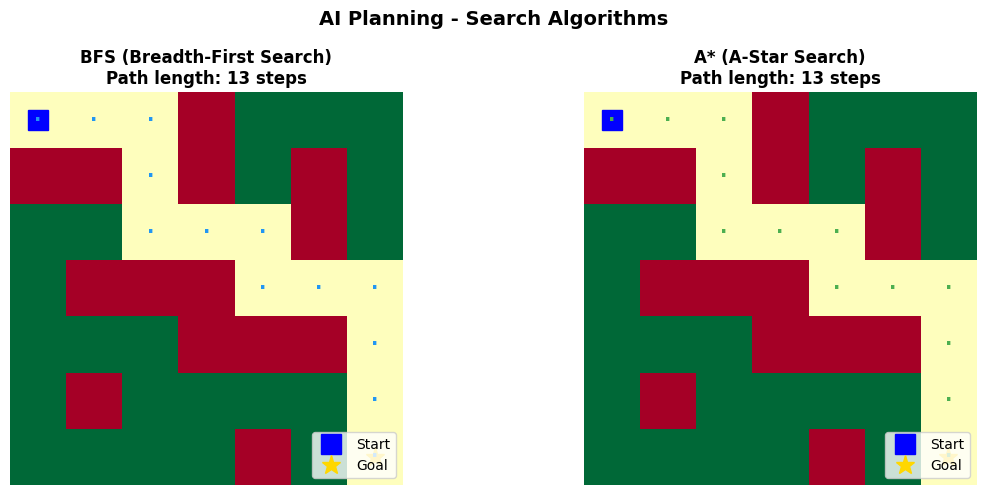

Algorithm  Path Length  Optimal  Uses Heuristic
      BFS           13     True           False
       A*           13     True            True


In [4]:
from collections import deque
import heapq

# ── BFS: shortest path in a grid ────────────────────────────────────────────
def bfs(grid, start, goal):
    queue = deque([(start, [start])])
    visited = {start}
    while queue:
        (r, c), path = queue.popleft()
        if (r, c) == goal: return path
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = r+dr, c+dc
            if 0<=nr<len(grid) and 0<=nc<len(grid[0]) and grid[nr][nc]!=1 and (nr,nc) not in visited:
                visited.add((nr,nc)); queue.append(((nr,nc), path+[(nr,nc)]))
    return []

# ── A*: heuristic-guided search ─────────────────────────────────────────────
def astar(grid, start, goal):
    def h(a,b): return abs(a[0]-b[0]) + abs(a[1]-b[1])
    heap = [(h(start,goal), 0, start, [start])]
    visited = {}
    while heap:
        f, g, node, path = heapq.heappop(heap)
        if node in visited: continue
        visited[node] = g
        if node == goal: return path
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = node[0]+dr, node[1]+dc
            if 0<=nr<len(grid) and 0<=nc<len(grid[0]) and grid[nr][nc]!=1:
                ng = g+1
                heapq.heappush(heap, (ng+h((nr,nc),goal), ng, (nr,nc), path+[(nr,nc)]))
    return []

# 0=open, 1=wall
grid = [
    [0,0,0,1,0,0,0],
    [1,1,0,1,0,1,0],
    [0,0,0,0,0,1,0],
    [0,1,1,1,0,0,0],
    [0,0,0,1,1,1,0],
    [0,1,0,0,0,0,0],
    [0,0,0,0,1,0,0],
]
start, goal = (0,0), (6,6)
bfs_path  = bfs(grid, start, goal)
astar_path = astar(grid, start, goal)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, path, title, color in zip(axes,
        [bfs_path, astar_path],
        ['BFS (Breadth-First Search)', 'A* (A-Star Search)'],
        ['#2196F3','#4CAF50']):
    g = np.array(grid, dtype=float)
    for (r,c) in path: g[r][c] = 0.5
    ax.imshow(g, cmap='RdYlGn_r', vmin=0, vmax=1)
    for (r,c) in path:
        ax.text(c, r, '·', ha='center', va='center', fontsize=14, color=color, fontweight='bold')
    ax.plot(start[1], start[0], 's', color='blue', ms=14, label='Start')
    ax.plot(goal[1],  goal[0],  '*', color='gold', ms=14, label='Goal')
    ax.set_title(f'{title}\nPath length: {len(path)} steps', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right'); ax.axis('off')

plt.suptitle('AI Planning - Search Algorithms', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_planning_search.png', dpi=130, bbox_inches='tight')
plt.show()

df = pd.DataFrame({'Algorithm':['BFS','A*'], 'Path Length':[len(bfs_path), len(astar_path)],
                   'Optimal':[True,True], 'Uses Heuristic':[False,True]})
print(df.to_string(index=False))

### 1.2 Knowledge Representation - Rule-Based Expert System

=== Expert System Diagnoses ===
                           Symptoms                        Diagnosis
              fever, cough, fatigue                     Possible Flu
    chest_pain, shortness_of_breath Possible Cardiac Event - Seek ER
              fever, rash, headache                 Possible Measles
headache, nausea, light_sensitivity                Possible Migraine


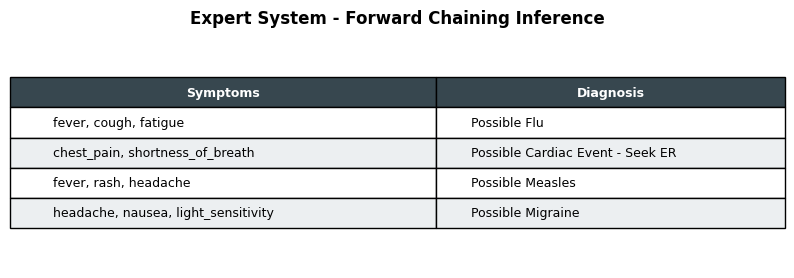

In [5]:
# ── Simple forward-chaining expert system (medical triage) ─────────────────
class ExpertSystem:
    def __init__(self):
        self.facts = set()
        self.rules = [
            ({'fever','cough','fatigue'},        'Possible Flu'),
            ({'fever','rash','headache'},         'Possible Measles'),
            ({'chest_pain','shortness_of_breath'},'Possible Cardiac Event - Seek ER'),
            ({'fever','sore_throat'},             'Possible Strep Throat'),
            ({'fatigue','weight_loss','cough'},   'Possible TB - See Doctor'),
            ({'headache','nausea','light_sensitivity'}, 'Possible Migraine'),
        ]
    def add_fact(self, fact): self.facts.add(fact)
    def reason(self):
        conclusions = []
        for conditions, conclusion in self.rules:
            if conditions.issubset(self.facts):
                conclusions.append(conclusion)
        return conclusions if conclusions else ['No diagnosis - insufficient symptoms']

es = ExpertSystem()
cases = [
    ['fever','cough','fatigue'],
    ['chest_pain','shortness_of_breath'],
    ['fever','rash','headache'],
    ['headache','nausea','light_sensitivity'],
]
rows = []
for symptoms in cases:
    es2 = ExpertSystem()
    for s in symptoms: es2.add_fact(s)
    diag = es2.reason()
    rows.append({'Symptoms': ', '.join(symptoms), 'Diagnosis': ' | '.join(diag)})

df = pd.DataFrame(rows)
print("=== Expert System Diagnoses ===")
print(df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
table = ax.table(cellText=df.values, colLabels=df.columns,
                 cellLoc='left', loc='center',
                 colWidths=[0.55, 0.45])
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1, 1.8)
for (row, col), cell in table.get_celld().items():
    if row == 0: cell.set_facecolor('#37474F'); cell.set_text_props(color='white', fontweight='bold')
    else: cell.set_facecolor('#ECEFF1' if row%2==0 else 'white')
plt.title('Expert System - Forward Chaining Inference', fontweight='bold', fontsize=12, pad=10)
plt.savefig(f'{SAVE_DIR}/01_expert_system.png', dpi=130, bbox_inches='tight')
plt.show()

### 1.x Fuzzy Logic — Fuzzy Inference System (AI Risk Assessment)
Fuzzy Logic handles partial truth: inputs belong to multiple categories
simultaneously with degrees of membership. This cell builds a fuzzy
inference system that assesses AI model deployment risk.

=== Fuzzy Logic — AI Deployment Risk Assessment ===
               Scenario  Accuracy  Data Size Risk Score Risk Level
   High Acc, Large Data        92         90       12.3        LOW
   High Acc, Small Data        88         20       50.0     MEDIUM
Medium Acc, Medium Data        65         55       50.0     MEDIUM
    Low Acc, Large Data        38         85       50.0     MEDIUM
    Low Acc, Small Data        25         15       86.4       HIGH


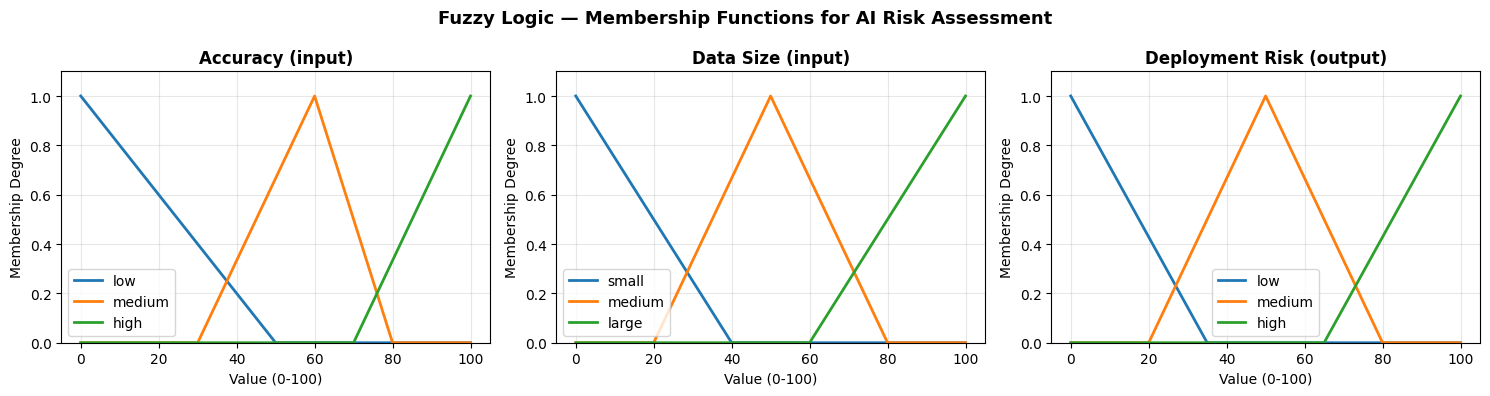

In [40]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-fuzzy'])

import skfuzzy as fuzz
from skfuzzy import control as ctrl

accuracy  = ctrl.Antecedent(np.arange(0, 101, 1), 'accuracy')
data_size = ctrl.Antecedent(np.arange(0, 101, 1), 'data_size')
risk      = ctrl.Consequent(np.arange(0, 101, 1), 'risk')

accuracy['low']    = fuzz.trimf(accuracy.universe,   [0,   0,  50])
accuracy['medium'] = fuzz.trimf(accuracy.universe,   [30,  60,  80])
accuracy['high']   = fuzz.trimf(accuracy.universe,   [70, 100, 100])

data_size['small']  = fuzz.trimf(data_size.universe, [0,   0,  40])
data_size['medium'] = fuzz.trimf(data_size.universe, [20,  50,  80])
data_size['large']  = fuzz.trimf(data_size.universe, [60, 100, 100])

risk['low']    = fuzz.trimf(risk.universe, [0,   0,  35])
risk['medium'] = fuzz.trimf(risk.universe, [20,  50,  80])
risk['high']   = fuzz.trimf(risk.universe, [65, 100, 100])

# ── All 9 combinations now covered ───────────────────────────────────────────
rules = [
    ctrl.Rule(accuracy['high']   & data_size['large'],  risk['low']),
    ctrl.Rule(accuracy['high']   & data_size['medium'], risk['low']),
    ctrl.Rule(accuracy['high']   & data_size['small'],  risk['medium']),  # ← was missing
    ctrl.Rule(accuracy['medium'] & data_size['large'],  risk['medium']),
    ctrl.Rule(accuracy['medium'] & data_size['medium'], risk['medium']),
    ctrl.Rule(accuracy['medium'] & data_size['small'],  risk['high']),
    ctrl.Rule(accuracy['low']    & data_size['large'],  risk['medium']),
    ctrl.Rule(accuracy['low']    & data_size['medium'], risk['high']),
    ctrl.Rule(accuracy['low']    & data_size['small'],  risk['high']),
]

risk_ctrl = ctrl.ControlSystem(rules)
risk_sim  = ctrl.ControlSystemSimulation(risk_ctrl)

test_cases = [
    ('High Acc, Large Data',    92, 90),
    ('High Acc, Small Data',    88, 20),
    ('Medium Acc, Medium Data', 65, 55),
    ('Low Acc, Large Data',     38, 85),
    ('Low Acc, Small Data',     25, 15),
]

rows_fz = []
for label, acc_val, data_val in test_cases:
    risk_sim.input['accuracy']  = acc_val
    risk_sim.input['data_size'] = data_val
    try:
        risk_sim.compute()
        risk_val = risk_sim.output['risk']
    except KeyError:
        # No rules fired — default to medium risk and flag it
        risk_val = 50.0
        print(f"  ⚠️  No rules fired for '{label}' ({acc_val}, {data_val}) — defaulting to 50")
    level = 'LOW' if risk_val < 35 else ('MEDIUM' if risk_val < 65 else 'HIGH')
    rows_fz.append({'Scenario': label, 'Accuracy': acc_val,
                    'Data Size': data_val,
                    'Risk Score': f'{risk_val:.1f}', 'Risk Level': level})

df_fz = pd.DataFrame(rows_fz)
print("=== Fuzzy Logic — AI Deployment Risk Assessment ===")
print(df_fz.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var, title in zip(axes,
        [accuracy, data_size, risk],
        ['Accuracy (input)', 'Data Size (input)', 'Deployment Risk (output)']):
    for label_mf, mf in var.terms.items():
        ax.plot(var.universe,
                fuzz.interp_membership(var.universe, mf.mf, var.universe),
                lw=2, label=label_mf)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Value (0-100)'); ax.set_ylabel('Membership Degree')
    ax.legend(); ax.set_ylim(0, 1.1); ax.grid(True, alpha=0.3)

plt.suptitle('Fuzzy Logic — Membership Functions for AI Risk Assessment',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01x_fuzzy_logic.png', dpi=130, bbox_inches='tight')
plt.show()

---
## Module 2 - Machine Learning

**Machine Learning** algorithms learn patterns from data without explicit programming.

| Type | Goal | Examples |
|------|------|---------|
| Supervised | Predict labeled output | Decision Trees, SVM, Regression |
| Unsupervised | Find hidden structure | K-Means, PCA, Autoencoders |
| Semi-Supervised | Mix of labeled + unlabeled | Label Propagation |
| Reinforcement | Learn via rewards | Q-Learning, PPO |


### Feature Engineering — Importance, Selection & Transformation
Feature engineering transforms raw data into representations that
models can learn from more effectively. Key techniques include
importance ranking, correlation analysis, and polynomial expansion.

=== Top 10 Features — Breast Cancer ===
             Feature  Importance
 mean concave points      0.1336
worst concave points      0.1244
     worst perimeter      0.1165
          worst area      0.1150
        worst radius      0.0693
      mean concavity      0.0665
      mean perimeter      0.0506
           mean area      0.0469
     worst concavity      0.0415
         mean radius      0.0348

Best accuracy: 0.988 using 19 features


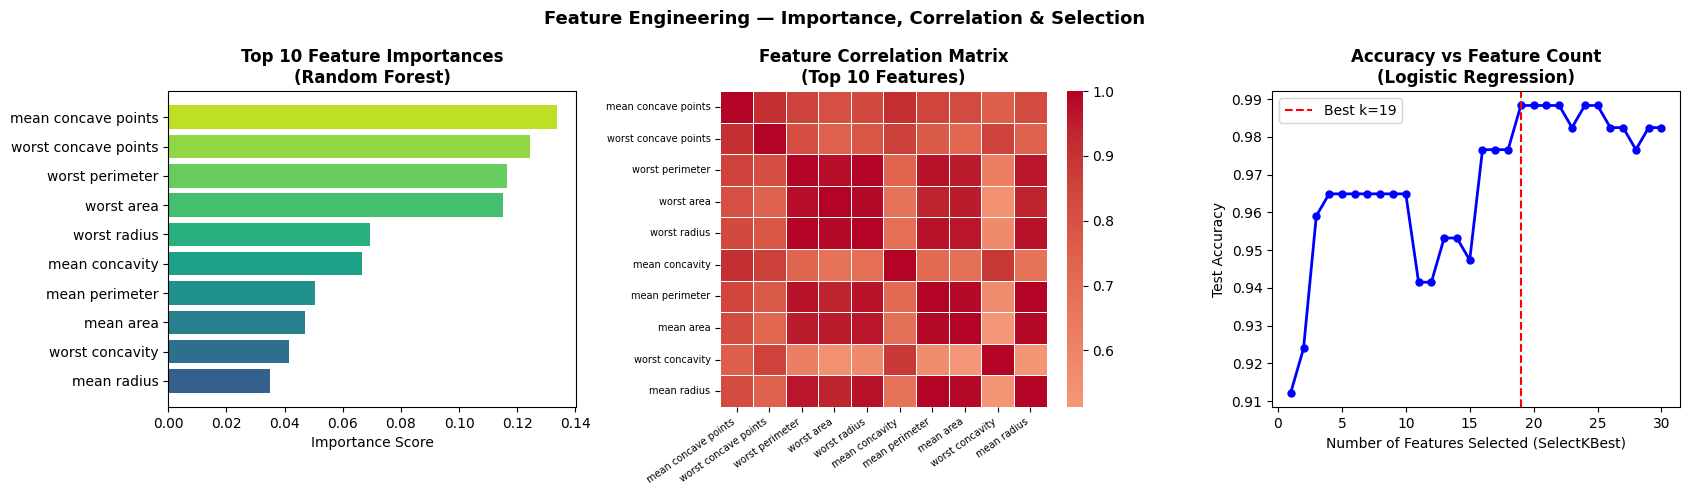

In [36]:
# ── Feature Engineering on Breast Cancer dataset ─────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.preprocessing import PolynomialFeatures
from sklearn.inspection import permutation_importance

bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
feat_names = bc.feature_names
X_tr_bc, X_te_bc, y_tr_bc, y_te_bc = train_test_split(X_bc, y_bc, test_size=0.3, random_state=42)
scaler_bc = StandardScaler()
X_tr_s = scaler_bc.fit_transform(X_tr_bc)
X_te_s = scaler_bc.transform(X_te_bc)

# 1 ── Feature importance via Random Forest ────────────────────────────────────
rf_bc = RandomForestClassifier(n_estimators=200, random_state=42)
rf_bc.fit(X_tr_s, y_tr_bc)
importances = rf_bc.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]
top10_idx   = sorted_idx[:10]

# 2 ── Correlation matrix (top 10 features) ───────────────────────────────────
df_bc = pd.DataFrame(X_bc, columns=feat_names)
corr  = df_bc[feat_names[top10_idx]].corr()

# 3 ── Effect of feature count on accuracy ────────────────────────────────────
acc_by_k = []
for k in range(1, 31):
    sel = SelectKBest(f_classif, k=k)
    Xk_tr = sel.fit_transform(X_tr_s, y_tr_bc)
    Xk_te = sel.transform(X_te_s)
    clf_k = LogisticRegression(max_iter=500, random_state=42)
    clf_k.fit(Xk_tr, y_tr_bc)
    acc_by_k.append(accuracy_score(y_te_bc, clf_k.predict(Xk_te)))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1: Feature importances
axes[0].barh(feat_names[top10_idx][::-1], importances[top10_idx][::-1],
             color=plt.cm.viridis(np.linspace(0.3, 0.9, 10)))
axes[0].set_title('Top 10 Feature Importances\n(Random Forest)', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Plot 2: Correlation heatmap
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Feature Correlation Matrix\n(Top 10 Features)', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right', fontsize=7)
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=7)

# Plot 3: Accuracy vs number of features selected
axes[2].plot(range(1,31), acc_by_k, 'b-o', lw=2, ms=5)
best_k = np.argmax(acc_by_k) + 1
axes[2].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[2].set_xlabel('Number of Features Selected (SelectKBest)')
axes[2].set_ylabel('Test Accuracy')
axes[2].set_title('Accuracy vs Feature Count\n(Logistic Regression)', fontweight='bold')
axes[2].legend()

df_fe = pd.DataFrame({'Feature': feat_names[top10_idx],
                       'Importance': importances[top10_idx].round(4)}).sort_values('Importance', ascending=False)
print("=== Top 10 Features — Breast Cancer ===")
print(df_fe.to_string(index=False))
print(f"\nBest accuracy: {max(acc_by_k):.3f} using {best_k} features")

plt.suptitle('Feature Engineering — Importance, Correlation & Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02x_feature_engineering.png', dpi=130, bbox_inches='tight')
plt.show()

### 2.1 Supervised Learning - Classification Comparison (Decision Tree · SVM · Ensemble)

=== Classifier Comparison on Iris Dataset ===
            Model Train Acc Test Acc CV Mean CV Std
    Decision Tree     0.971    1.000   0.953 ±0.034
        SVM (RBF)     0.962    1.000   0.967 ±0.021
    Random Forest     1.000    1.000   0.967 ±0.021
Gradient Boosting     1.000    1.000   0.967 ±0.021
              KNN     0.952    1.000   0.960 ±0.025
     Logistic Reg     0.962    1.000   0.960 ±0.039


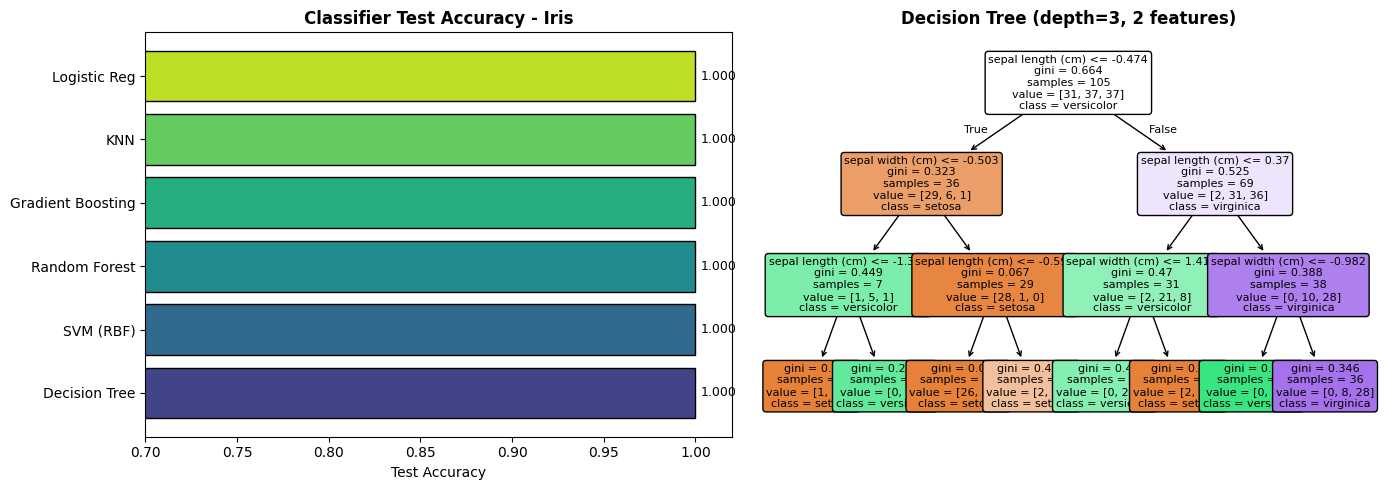

In [6]:
# ── Load Iris dataset ───────────────────────────────────────────────────────
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)

classifiers = {
    'Decision Tree':     DecisionTreeClassifier(max_depth=4, random_state=42),
    'SVM (RBF)':         SVC(kernel='rbf', C=1.0, random_state=42),
    'Random Forest':     RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'KNN':               KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg':      LogisticRegression(max_iter=200, random_state=42),
}

results = []
for name, clf in classifiers.items():
    clf.fit(Xs_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(Xs_train))
    test_acc  = accuracy_score(y_test,  clf.predict(Xs_test))
    cv_scores = cross_val_score(clf, scaler.transform(X), y, cv=5)
    results.append({'Model': name, 'Train Acc': f'{train_acc:.3f}',
                    'Test Acc': f'{test_acc:.3f}',
                    'CV Mean': f'{cv_scores.mean():.3f}',
                    'CV Std':  f'±{cv_scores.std():.3f}'})

df_results = pd.DataFrame(results)
print("=== Classifier Comparison on Iris Dataset ===")
print(df_results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Bar chart - test accuracy
test_accs = [float(r['Test Acc']) for r in results]
cv_means  = [float(r['CV Mean']) for r in results]
names     = [r['Model'] for r in results]
colors    = plt.cm.viridis(np.linspace(0.2, 0.9, len(names)))
axes[0].barh(names, test_accs, color=colors, edgecolor='black')
axes[0].set_xlim(0.7, 1.02)
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Classifier Test Accuracy - Iris', fontweight='bold')
for i, v in enumerate(test_accs):
    axes[0].text(v+0.003, i, f'{v:.3f}', va='center', fontsize=9)

# Decision Tree visualization (2 features for readability)
from sklearn.tree import plot_tree
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(Xs_train[:, :2], y_train)
plot_tree(dt, feature_names=iris.feature_names[:2],
          class_names=iris.target_names,
          filled=True, rounded=True, fontsize=8, ax=axes[1])
axes[1].set_title('Decision Tree (depth=3, 2 features)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_ml_classifiers.png', dpi=130, bbox_inches='tight')
plt.show()

### 2.x Semi-Supervised Learning — Label Spreading on Digits
Semi-supervised learning uses a small number of labeled examples
plus many unlabeled ones. Label Spreading propagates labels through
a graph built on feature similarity.

=== Semi-Supervised vs Supervised — Digits Dataset ===
Labeled %  N Labeled SSL Acc Supervised Acc SSL Gain
       5%         63   0.854          0.731   +0.122
      10%        126   0.935          0.854   +0.081
      20%        252   0.961          0.924   +0.037
      50%        629   0.972          0.963   +0.009
     100%       1257   0.980          0.974   +0.006


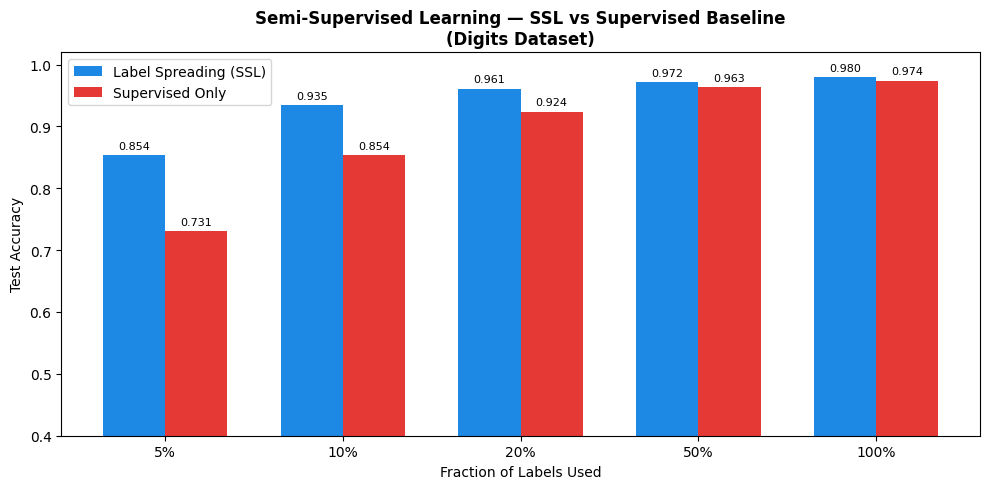

In [35]:
# ── Label Spreading: 10% labeled, 90% unlabeled ───────────────────────────────
from sklearn.semi_supervised import LabelSpreading, LabelPropagation

digits = load_digits()
X_d, y_d = digits.data, digits.target
X_d_s = StandardScaler().fit_transform(X_d)
X_tr, X_te, y_tr, y_te = train_test_split(X_d_s, y_d, test_size=0.3, random_state=42)

# Mask 90% of training labels → -1 means unlabeled
def mask_labels(y, frac_labeled=0.10, seed=42):
    rng = np.random.default_rng(seed)
    y_masked = y.copy()
    unlabeled = rng.choice(len(y), size=int(len(y)*(1-frac_labeled)), replace=False)
    y_masked[unlabeled] = -1
    return y_masked

results_ssl = []
for pct in [0.05, 0.10, 0.20, 0.50, 1.00]:
    y_masked = mask_labels(y_tr, frac_labeled=pct)
    n_labeled = (y_masked != -1).sum()

    # Semi-supervised
    ls = LabelSpreading(kernel='knn', n_neighbors=7, max_iter=30)
    ls.fit(X_tr, y_masked)
    ssl_acc = accuracy_score(y_te, ls.predict(X_te))

    # Supervised baseline (same labeled subset only)
    labeled_mask = y_masked != -1
    sup = RandomForestClassifier(n_estimators=100, random_state=42)
    sup.fit(X_tr[labeled_mask], y_tr[labeled_mask])
    sup_acc = accuracy_score(y_te, sup.predict(X_te))

    results_ssl.append({'Labeled %': f'{pct*100:.0f}%',
                        'N Labeled': n_labeled,
                        'SSL Acc':  f'{ssl_acc:.3f}',
                        'Supervised Acc': f'{sup_acc:.3f}',
                        'SSL Gain': f'{ssl_acc - sup_acc:+.3f}'})

df_ssl = pd.DataFrame(results_ssl)
print("=== Semi-Supervised vs Supervised — Digits Dataset ===")
print(df_ssl.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x_pos  = np.arange(len(df_ssl))
width  = 0.35
ssl_vals = [float(r['SSL Acc'])        for r in results_ssl]
sup_vals = [float(r['Supervised Acc']) for r in results_ssl]
ax.bar(x_pos - width/2, ssl_vals, width, label='Label Spreading (SSL)', color='#1E88E5')
ax.bar(x_pos + width/2, sup_vals, width, label='Supervised Only',       color='#E53935')
ax.set_xticks(x_pos)
ax.set_xticklabels([r['Labeled %'] for r in results_ssl])
ax.set_xlabel('Fraction of Labels Used')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(0.4, 1.02)
ax.set_title('Semi-Supervised Learning — SSL vs Supervised Baseline\n(Digits Dataset)',
             fontweight='bold')
ax.legend()
for i, (s, p) in enumerate(zip(ssl_vals, sup_vals)):
    ax.text(i - width/2, s + 0.01, f'{s:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, p + 0.01, f'{p:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02x_semi_supervised.png', dpi=130, bbox_inches='tight')
plt.show()

### 2.2 Regression - Linear & Polynomial

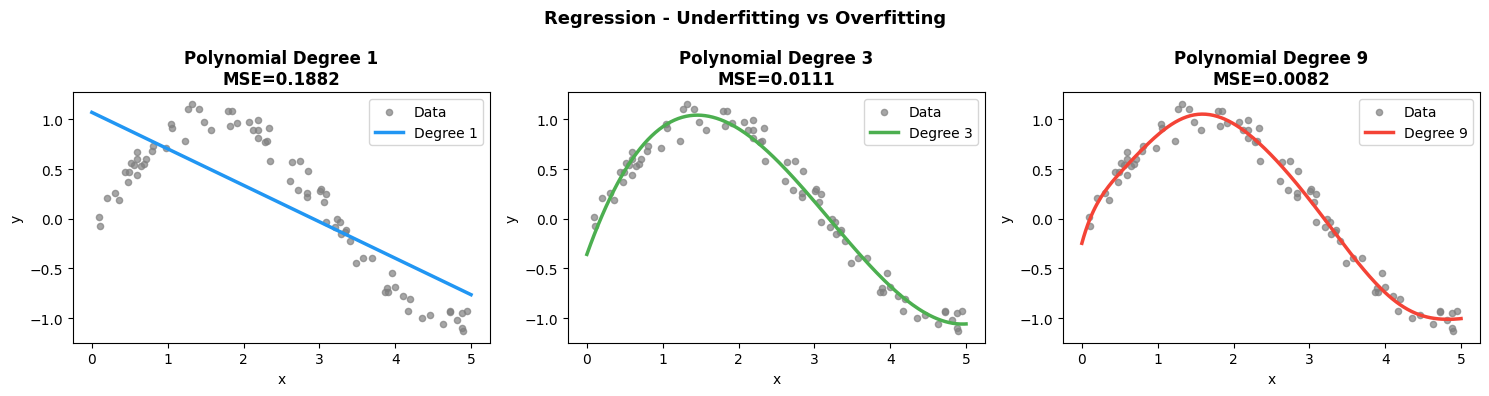

In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(0)
X_r = np.sort(5 * np.random.rand(80, 1), axis=0)
y_r = np.sin(X_r).ravel() + np.random.normal(0, 0.1, 80)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
degrees = [1, 3, 9]
colors  = ['#2196F3','#4CAF50','#F44336']
for ax, deg, col in zip(axes, degrees, colors):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(X_r, y_r)
    X_plot = np.linspace(0, 5, 200).reshape(-1, 1)
    ax.scatter(X_r, y_r, s=20, alpha=0.7, color='gray', label='Data')
    ax.plot(X_plot, model.predict(X_plot), color=col, lw=2.5,
            label=f'Degree {deg}')
    mse = mean_squared_error(y_r, model.predict(X_r))
    ax.set_title(f'Polynomial Degree {deg}\nMSE={mse:.4f}', fontweight='bold')
    ax.legend(); ax.set_xlabel('x'); ax.set_ylabel('y')
plt.suptitle('Regression - Underfitting vs Overfitting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_regression.png', dpi=130, bbox_inches='tight')
plt.show()

### 2.3 Unsupervised Learning - K-Means Clustering & PCA

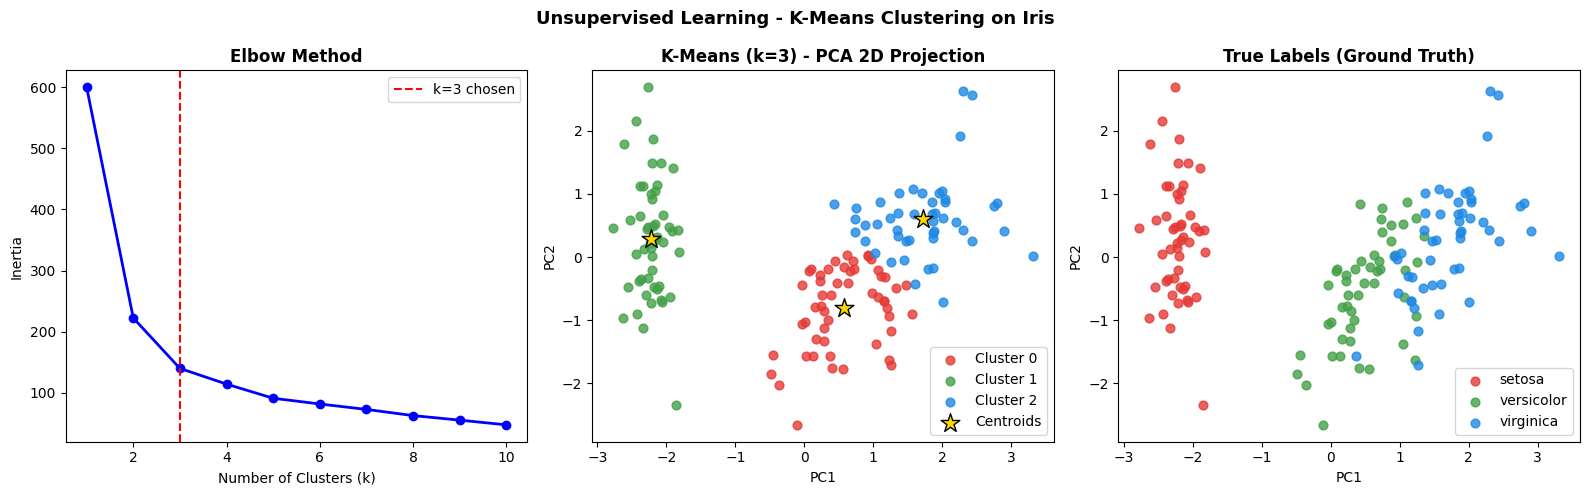

PCA Explained Variance: PC1=73.0%  PC2=22.9%  Total=95.8%


In [8]:
# ── K-Means on Iris ─────────────────────────────────────────────────────────
iris = load_iris()
X, y = iris.data, iris.target
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# Elbow method
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(Xs); inertias.append(km.inertia_)

# PCA to 2D for visualization
pca = PCA(n_components=2)
X2d = pca.fit_transform(Xs)
km  = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km.fit_predict(Xs)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# Elbow
axes[0].plot(K_range, inertias, 'bo-', lw=2)
axes[0].axvline(3, color='red', linestyle='--', label='k=3 chosen')
axes[0].set_xlabel('Number of Clusters (k)'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold'); axes[0].legend()

# K-Means result
palette = ['#E53935','#43A047','#1E88E5']
for i in range(3):
    mask = labels == i
    axes[1].scatter(X2d[mask,0], X2d[mask,1], s=40, c=palette[i], label=f'Cluster {i}', alpha=0.8)
centers_2d = pca.transform(km.cluster_centers_)
axes[1].scatter(centers_2d[:,0], centers_2d[:,1], s=200, c='gold', marker='*',
                edgecolors='black', zorder=5, label='Centroids')
axes[1].set_title('K-Means (k=3) - PCA 2D Projection', fontweight='bold')
axes[1].legend(); axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

# True labels for comparison
for i in range(3):
    mask = y == i
    axes[2].scatter(X2d[mask,0], X2d[mask,1], s=40, c=palette[i],
                    label=iris.target_names[i], alpha=0.8)
axes[2].set_title('True Labels (Ground Truth)', fontweight='bold')
axes[2].legend(); axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')

plt.suptitle('Unsupervised Learning - K-Means Clustering on Iris', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_kmeans_pca.png', dpi=130, bbox_inches='tight')
plt.show()

var = pca.explained_variance_ratio_
print(f"PCA Explained Variance: PC1={var[0]*100:.1f}%  PC2={var[1]*100:.1f}%  Total={sum(var)*100:.1f}%")

### 2.4 Dimensionality Reduction - PCA vs t-SNE

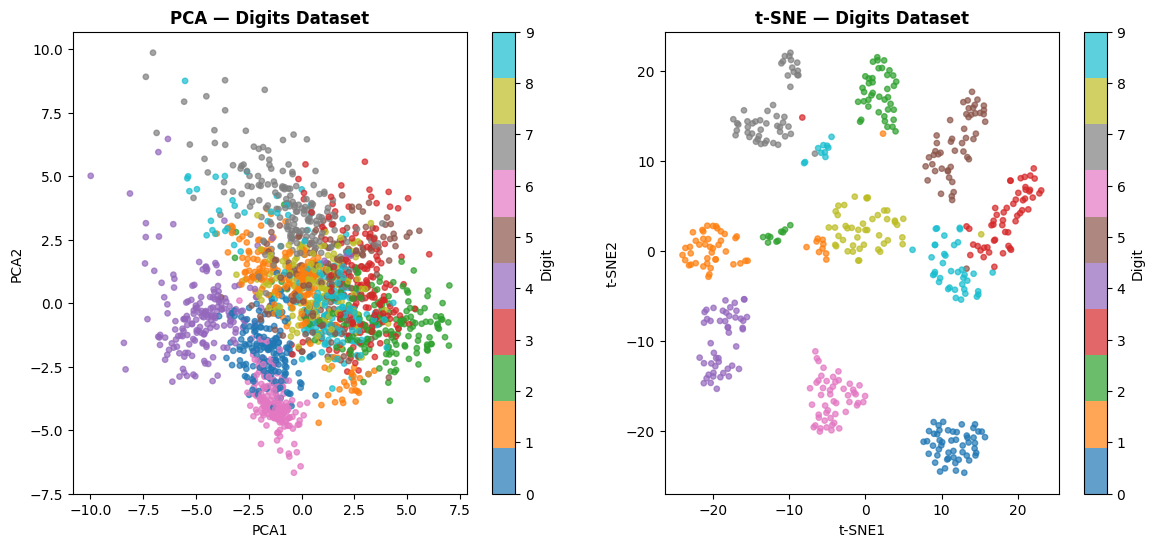

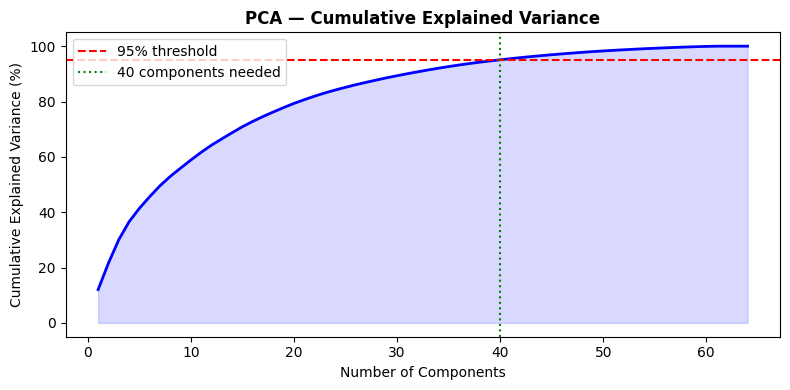

Components to explain 95% variance: 40 (out of 64 original features)


In [10]:
digits = load_digits()
Xd, yd = digits.data, digits.target
Xd_scaled = StandardScaler().fit_transform(Xd)

pca_full  = PCA(n_components=2, random_state=42)
tsne_full = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=500)

X_pca  = pca_full.fit_transform(Xd_scaled)
X_tsne = tsne_full.fit_transform(Xd_scaled[:500])
y_sub  = yd[:500]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA plot
sc1 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=yd, cmap='tab10', s=15, alpha=0.7)
plt.colorbar(sc1, ax=axes[0], ticks=range(10), label='Digit')
axes[0].set_title('PCA — Digits Dataset', fontweight='bold')
axes[0].set_xlabel('PCA1'); axes[0].set_ylabel('PCA2')

# t-SNE plot
sc2 = axes[1].scatter(X_tsne[:,0], X_tsne[:,1], c=y_sub, cmap='tab10', s=15, alpha=0.7)
plt.colorbar(sc2, ax=axes[1], ticks=range(10), label='Digit')
axes[1].set_title('t-SNE — Digits Dataset', fontweight='bold')
axes[1].set_xlabel('t-SNE1'); axes[1].set_ylabel('t-SNE2')

pca64 = PCA()
pca64.fit(Xd_scaled)
cumvar = np.cumsum(pca64.explained_variance_ratio_)

fig2, ax2 = plt.subplots(figsize=(8,4))
ax2.plot(range(1, len(cumvar)+1), cumvar*100, 'b-', lw=2)
ax2.axhline(95, color='red', linestyle='--', label='95% threshold')
n95 = np.argmax(cumvar >= 0.95) + 1
ax2.axvline(n95, color='green', linestyle=':', label=f'{n95} components needed')
ax2.fill_between(range(1, len(cumvar)+1), cumvar*100, alpha=0.15, color='blue')
ax2.set_xlabel('Number of Components'); ax2.set_ylabel('Cumulative Explained Variance (%)')
ax2.set_title('PCA — Cumulative Explained Variance', fontweight='bold')
ax2.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_pca_tsne.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Components to explain 95% variance: {n95} (out of 64 original features)")

### 2.5 Ensemble Learning - Bagging, Boosting & Voting

                  Model  Test Accuracy
   Single Decision Tree       0.773333
    AdaBoost (Boosting)       0.826667
        Voting Ensemble       0.870000
      Gradient Boosting       0.906667
Random Forest (Bagging)       0.916667


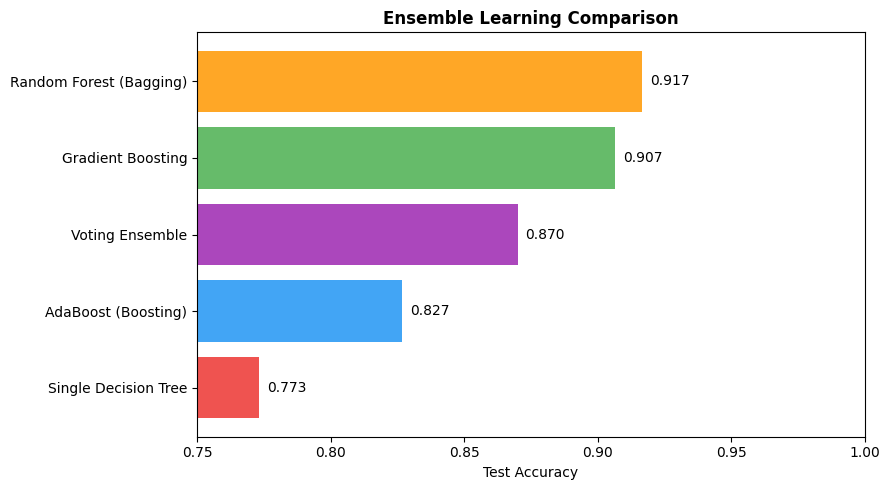

In [11]:
from sklearn.datasets import make_classification
X_e, y_e = make_classification(n_samples=1000, n_features=20, n_informative=10,
                                n_redundant=5, random_state=42)
X_etr, X_ete, y_etr, y_ete = train_test_split(X_e, y_e, test_size=0.3, random_state=42)
scaler_e = StandardScaler()
X_etr_s = scaler_e.fit_transform(X_etr)
X_ete_s  = scaler_e.transform(X_ete)

base_dt  = DecisionTreeClassifier(max_depth=3, random_state=42)
rf       = RandomForestClassifier(n_estimators=100, random_state=42)
gb       = GradientBoostingClassifier(n_estimators=100, random_state=42)
ada      = AdaBoostClassifier(n_estimators=100, random_state=42)
vote     = VotingClassifier([('rf', rf), ('gb', gb), ('ada', ada)], voting='soft')

ensemble_models = {
    'Single Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest (Bagging)': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost (Boosting)':     AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':       GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Voting Ensemble':         VotingClassifier([
        ('dt', DecisionTreeClassifier(max_depth=3, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
        ('lr', LogisticRegression(random_state=42))], voting='soft'),
}

ens_results = []
for name, m in ensemble_models.items():
    m.fit(X_etr_s, y_etr)
    acc = accuracy_score(y_ete, m.predict(X_ete_s))
    ens_results.append({'Model': name, 'Test Accuracy': acc})

df_ens = pd.DataFrame(ens_results).sort_values('Test Accuracy', ascending=True)
print(df_ens.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(df_ens['Model'], df_ens['Test Accuracy'],
               color=['#EF5350','#42A5F5','#AB47BC','#66BB6A','#FFA726'])
ax.set_xlim(0.75, 1.0)
for bar, acc in zip(bars, df_ens['Test Accuracy']):
    ax.text(acc + 0.003, bar.get_y() + bar.get_height()/2,
            f'{acc:.3f}', va='center', fontsize=10)
ax.set_xlabel('Test Accuracy'); ax.set_title('Ensemble Learning Comparison', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_ensemble.png', dpi=130, bbox_inches='tight')
plt.show()

---
## Module 3 - Neural Networks

**Neural Networks** are the core building block of modern AI - loosely inspired by biological neurons.

| Concept | Description |
|---------|-------------|
| Perceptron | Single neuron: weighted sum + threshold |
| MLP | Multiple layers of perceptrons |
| Backpropagation | Gradient-based weight update algorithm |
| Activation Functions | Non-linearities: ReLU, Sigmoid, Tanh, Softmax |
| CNN | Shared weight filters for spatial data |
| RNN / LSTM | Handles sequential/temporal data |
| Self-Organizing Maps | Unsupervised competitive learning topology |


### 3.1 Activation Functions - Visualization & Comparison

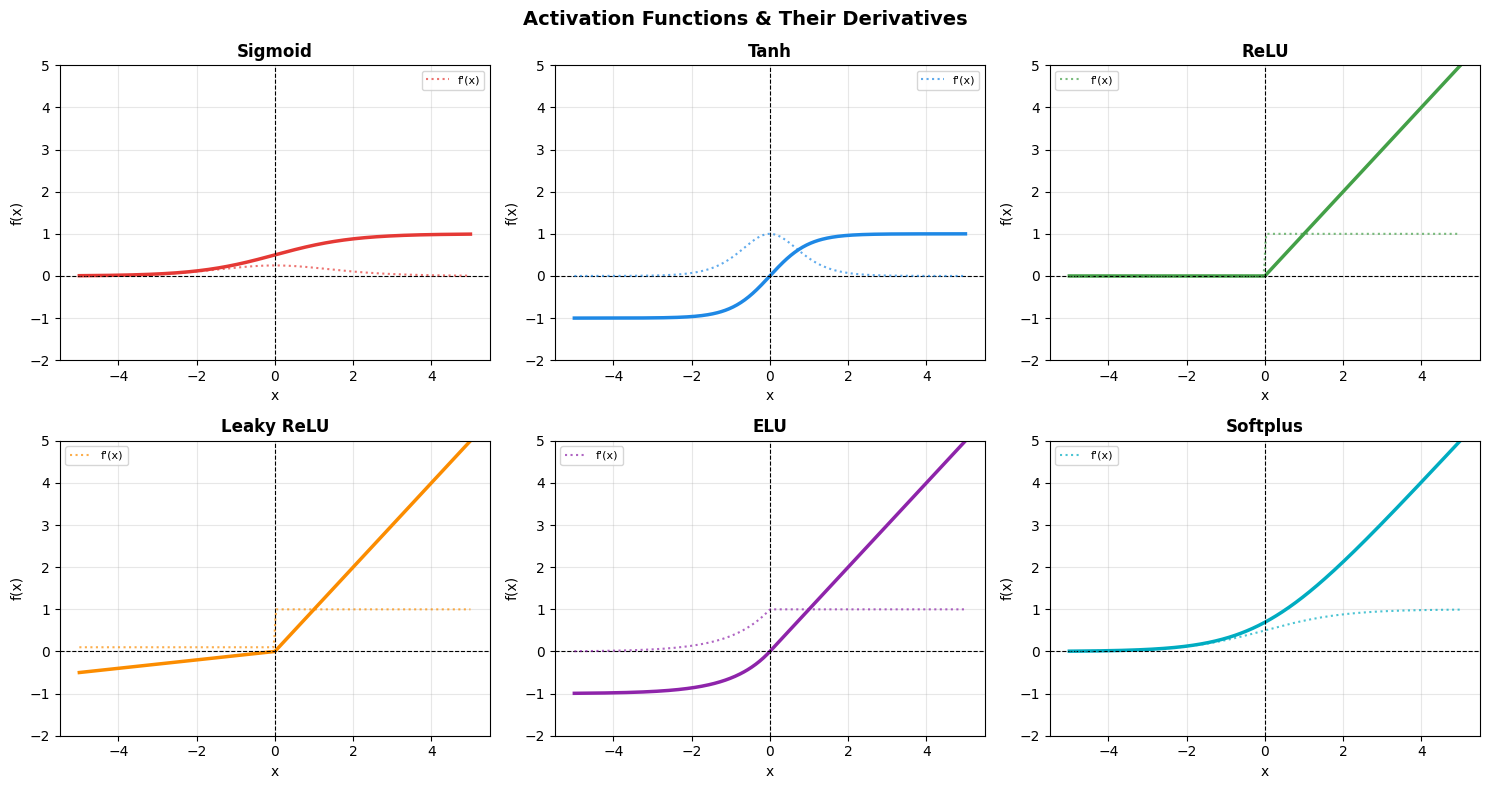

  Function  Range Vanishing Grad Risk      Typical Use Computationally
   Sigmoid  (0,1)                High  Output (binary)        Moderate
      Tanh (-1,1)              Medium           Hidden        Moderate
      ReLU  [0,∞)     None (positive) Hidden (default)            Fast
Leaky ReLU (-∞,∞)                 Low           Hidden            Fast
       ELU (-1,∞)                 Low           Hidden        Moderate


In [12]:
x = np.linspace(-5, 5, 400)
activations = {
    'Sigmoid':     (1 / (1 + np.exp(-x)),   '#E53935'),
    'Tanh':        (np.tanh(x),              '#1E88E5'),
    'ReLU':        (np.maximum(0, x),        '#43A047'),
    'Leaky ReLU':  (np.where(x>0, x, 0.1*x),'#FB8C00'),
    'ELU':         (np.where(x>0, x, np.exp(x)-1), '#8E24AA'),
    'Softplus':    (np.log(1+np.exp(x)),     '#00ACC1'),
}
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, (name, (y_act, col)) in zip(axes, activations.items()):
    ax.plot(x, y_act, color=col, lw=2.5)
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xlabel('x'); ax.set_ylabel('f(x)')
    ax.set_ylim(-2, 5); ax.grid(True, alpha=0.3)
    # Add derivative
    dy = np.gradient(y_act, x)
    ax.plot(x, dy, color=col, lw=1.5, linestyle=':', alpha=0.7, label="f'(x)")
    ax.legend(fontsize=8)
plt.suptitle('Activation Functions & Their Derivatives', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_activation_functions.png', dpi=130, bbox_inches='tight')
plt.show()

# Properties table
df_act = pd.DataFrame({
    'Function':   ['Sigmoid','Tanh','ReLU','Leaky ReLU','ELU'],
    'Range':      ['(0,1)','(-1,1)','[0,∞)','(-∞,∞)','(-1,∞)'],
    'Vanishing Grad Risk': ['High','Medium','None (positive)','Low','Low'],
    'Typical Use': ['Output (binary)','Hidden','Hidden (default)','Hidden','Hidden'],
    'Computationally': ['Moderate','Moderate','Fast','Fast','Moderate'],
})
print(df_act.to_string(index=False))

### 3.2 Perceptron - From Scratch (AND / OR Gate)

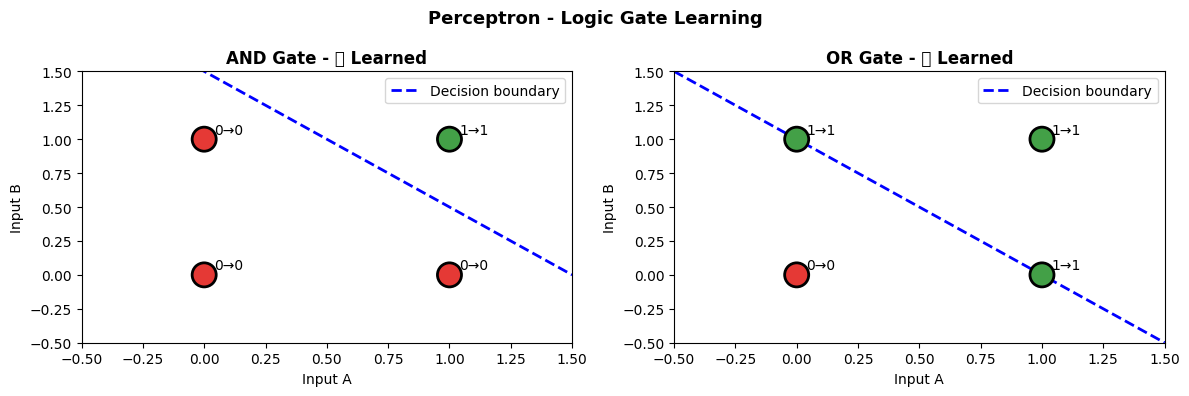

AND predictions: [0 1 1 1]


In [13]:
class Perceptron:
    def __init__(self, lr=0.1, epochs=100):
        self.lr, self.epochs = lr, epochs
    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        self.errors_ = []
        for _ in range(self.epochs):
            err = 0
            for xi, yi in zip(X, y):
                pred = self.predict(xi)
                delta = self.lr * (yi - pred)
                self.w += delta * xi
                self.b += delta
                err   += int(delta != 0)
            self.errors_.append(err)
    def predict(self, X):
        return np.where(np.dot(X, self.w) + self.b >= 0.5, 1, 0)

# Logic gates
gates = {
    'AND': (np.array([[0,0],[0,1],[1,0],[1,1]]), np.array([0,0,0,1])),
    'OR':  (np.array([[0,0],[0,1],[1,0],[1,1]]), np.array([0,1,1,1])),
}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (gate, (Xg, yg)) in zip(axes, gates.items()):
    p = Perceptron(lr=0.1, epochs=30)
    p.fit(Xg, yg)
    preds = p.predict(Xg)
    correct = (preds == yg).all()
    colors = ['#E53935' if l==0 else '#43A047' for l in yg]
    ax.scatter(Xg[:,0], Xg[:,1], c=colors, s=300, zorder=3, edgecolors='black', lw=2)
    for i,(xi,yi_l,pred) in enumerate(zip(Xg,yg,preds)):
        ax.text(xi[0]+0.04, xi[1]+0.04, f'{yi_l}→{pred}', fontsize=10)
    if p.w[1] != 0:
        xline = np.linspace(-0.5,1.5,100)
        yline = (-p.w[0]*xline - p.b + 0.5) / p.w[1]
        ax.plot(xline, yline, 'b--', lw=2, label='Decision boundary')
    ax.set_xlim(-0.5,1.5); ax.set_ylim(-0.5,1.5)
    ax.set_title(f'{gate} Gate - {"✅ Learned" if correct else "❌ Not separable"}', fontweight='bold')
    ax.set_xlabel('Input A'); ax.set_ylabel('Input B'); ax.legend()
plt.suptitle('Perceptron - Logic Gate Learning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_perceptron.png', dpi=130, bbox_inches='tight')
plt.show()
print("AND predictions:", p.predict(gates['AND'][0]))

### 3.3 Multi-Layer Perceptron (MLP) - MNIST Handwritten Digits

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MLP_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8543 - loss: 0.4782 - val_accuracy: 0.9588 - val_loss: 0.1377
Epoch 2/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9447 - loss: 0.1853 - val_accuracy: 0.9732 - val_loss: 0.0980
Epoch 3/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9590 - loss: 0.1377 - val_accuracy: 0.9762 - val_loss: 0.0855
Epoch 4/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9659 - loss: 0.1098 - val_accuracy: 0.9742 - val_loss: 0.0781
Epoch 5/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9714 - loss: 0.0927 - val_accuracy: 0.9787 - val_loss: 0.0693
Epoch 6/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9750 - loss: 0.0820 - val_accuracy: 0.9788 - val_loss: 0.0712
Epoch 7/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9773 - loss: 0.0712 - val_accuracy: 0.9808 - val_loss: 0.0682
Epoch 8/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9794 - loss: 0.0654 - val_accuracy: 0

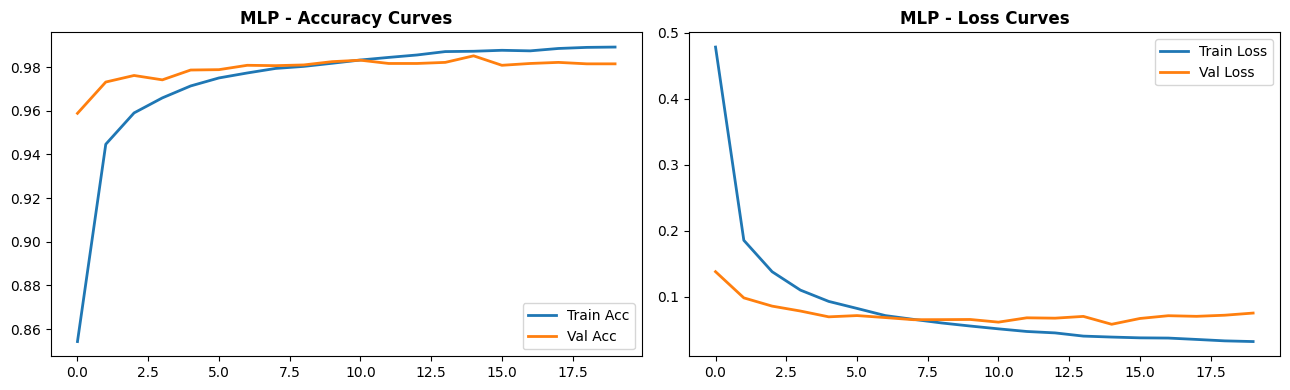

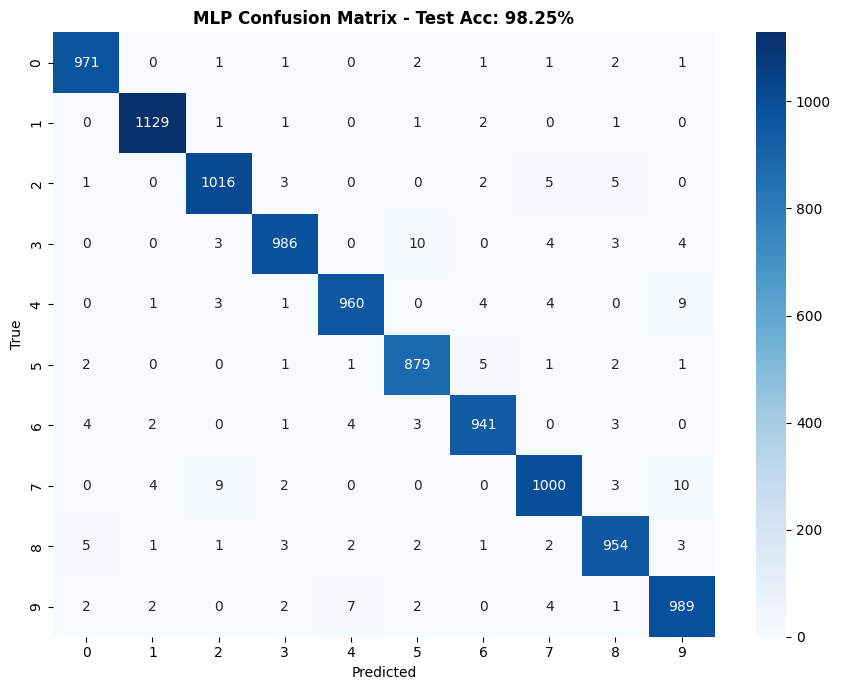

In [14]:
# ── Load MNIST ───────────────────────────────────────────────────────────────
(X_tr, y_tr), (X_te, y_te) = mnist.load_data()
X_tr = X_tr.reshape(-1, 784).astype('float32') / 255.0
X_te = X_te.reshape(-1, 784).astype('float32') / 255.0
Y_tr = to_categorical(y_tr, 10); Y_te = to_categorical(y_te, 10)

# ── Build MLP ────────────────────────────────────────────────────────────────
mlp = keras.Sequential([
    layers.Dense(256, activation='relu',    input_shape=(784,), name='hidden1'),
    layers.Dropout(0.3, name='dropout1'),
    layers.Dense(128, activation='relu',    name='hidden2'),
    layers.Dropout(0.2, name='dropout2'),
    layers.Dense(64,  activation='relu',    name='hidden3'),
    layers.Dense(10,  activation='softmax', name='output'),
], name='MLP_MNIST')
mlp.summary()

mlp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
history_mlp = mlp.fit(X_tr, Y_tr, epochs=25, batch_size=256,
                       validation_split=0.1, callbacks=[early_stop], verbose=1)

# ── Evaluate ─────────────────────────────────────────────────────────────────
_, test_acc = mlp.evaluate(X_te, Y_te, verbose=0)
print(f"\n✅ MLP Test Accuracy: {test_acc*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_mlp.history['accuracy'],     label='Train Acc', lw=2)
axes[0].plot(history_mlp.history['val_accuracy'], label='Val Acc',   lw=2)
axes[0].set_title('MLP - Accuracy Curves', fontweight='bold'); axes[0].legend()
axes[1].plot(history_mlp.history['loss'],     label='Train Loss', lw=2)
axes[1].plot(history_mlp.history['val_loss'], label='Val Loss',   lw=2)
axes[1].set_title('MLP - Loss Curves', fontweight='bold'); axes[1].legend()
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_mlp_mnist.png', dpi=130, bbox_inches='tight'); plt.show()

# ── Confusion matrix ─────────────────────────────────────────────────────────
y_pred = np.argmax(mlp.predict(X_te, verbose=0), axis=1)
cm = confusion_matrix(y_te, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=range(10), yticklabels=range(10))
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'MLP Confusion Matrix - Test Acc: {test_acc*100:.2f}%', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/03_mlp_confusion.png', dpi=130, bbox_inches='tight'); plt.show()

### 3.x Backpropagation — Manual Forward & Backward Pass Visualization
Backpropagation computes gradients layer-by-layer using the chain rule,
then updates weights via gradient descent. This cell builds a 2-layer
network from scratch — no Keras — so every gradient is visible.

Final predictions vs truth:
Input  True  Pred  Raw Output
[0,0]     0     0      0.0562
[0,1]     1     1      0.9507
[1,0]     1     1      0.9506
[1,1]     0     0      0.0512


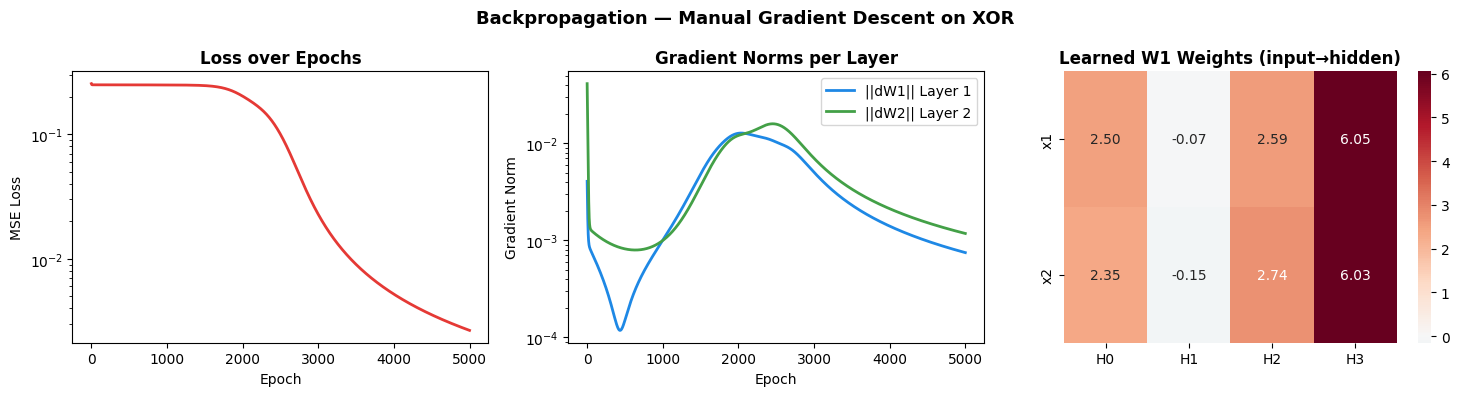

In [34]:
# ── Backpropagation from scratch on XOR problem ──────────────────────────────
def sigmoid(z):      return 1 / (1 + np.exp(-z))
def sigmoid_d(z):    return sigmoid(z) * (1 - sigmoid(z))
def mse(y, yhat):    return np.mean((y - yhat)**2)

np.random.seed(42)
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([[0],[1],[1],[0]],         dtype=float)

# Weights: input(2) → hidden(4) → output(1)
W1 = np.random.randn(2, 4) * 0.5
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1) * 0.5
b2 = np.zeros((1, 1))

lr = 0.5
losses, W1_norms, W2_norms = [], [], []

for epoch in range(5000):
    # ── Forward pass ──────────────────────────────────────────────────────
    Z1   = X_xor @ W1 + b1          # (4,4)
    A1   = sigmoid(Z1)              # hidden activations
    Z2   = A1  @ W2 + b2            # (4,1)
    A2   = sigmoid(Z2)              # output
    loss = mse(y_xor, A2)

    # ── Backward pass (chain rule) ────────────────────────────────────────
    dL_A2 = -2 * (y_xor - A2) / len(y_xor)
    dA2   = sigmoid_d(Z2)
    dZ2   = dL_A2 * dA2

    dW2   = A1.T @ dZ2
    db2   = dZ2.sum(axis=0, keepdims=True)

    dA1   = dZ2 @ W2.T
    dZ1   = dA1 * sigmoid_d(Z1)
    dW1   = X_xor.T @ dZ1
    db1   = dZ1.sum(axis=0, keepdims=True)

    # ── Weight update ─────────────────────────────────────────────────────
    W2 -= lr * dW2;  b2 -= lr * db2
    W1 -= lr * dW1;  b1 -= lr * db1

    losses.append(loss)
    W1_norms.append(np.linalg.norm(dW1))
    W2_norms.append(np.linalg.norm(dW2))

print("Final predictions vs truth:")
preds = (A2 > 0.5).astype(int)
df_bp = pd.DataFrame({'Input': ['[0,0]','[0,1]','[1,0]','[1,1]'],
                       'True':  y_xor.ravel().astype(int),
                       'Pred':  preds.ravel(),
                       'Raw Output': A2.ravel().round(4)})
print(df_bp.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(losses, color='#E53935', lw=2)
axes[0].set_title('Loss over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_yscale('log')

axes[1].plot(W1_norms, label='||dW1|| Layer 1', color='#1E88E5', lw=2)
axes[1].plot(W2_norms, label='||dW2|| Layer 2', color='#43A047', lw=2)
axes[1].set_title('Gradient Norms per Layer', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Gradient Norm')
axes[1].legend(); axes[1].set_yscale('log')

# Weight heatmap final W1
sns.heatmap(W1, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[2], xticklabels=[f'H{i}' for i in range(4)],
            yticklabels=['x1','x2'])
axes[2].set_title('Learned W1 Weights (input→hidden)', fontweight='bold')

plt.suptitle('Backpropagation — Manual Gradient Descent on XOR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03x_backpropagation.png', dpi=130, bbox_inches='tight')
plt.show()

### 3.4 Convolutional Neural Network (CNN) - MNIST

Model: "CNN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,954 (1.75 MB)

 Trainable params: 458,762 (1.75 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.9250 - loss: 0.2469 - val_accuracy: 0.8407 - val_loss: 0.9162
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9812 - loss: 0.0634 - val_accuracy: 0.9703 - val_loss: 0.1088
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9866 - loss: 0.0451 - val_accuracy: 0.9905 - val_loss: 0.0316
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9904 - loss: 0.0312 - val_accuracy: 0.9893 - val_loss: 0.0355
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9912 - loss: 0.0282 - val_accuracy: 0.9905 - val_loss: 0.0333
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9924 - loss: 0.0245 - val_accuracy: 0.9907 - val_loss: 0.0346
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9942 - loss: 0.0180 - val_accuracy: 0.9930 - val_loss: 0.0279
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9952 - loss: 0.0153 - val_accuracy: 

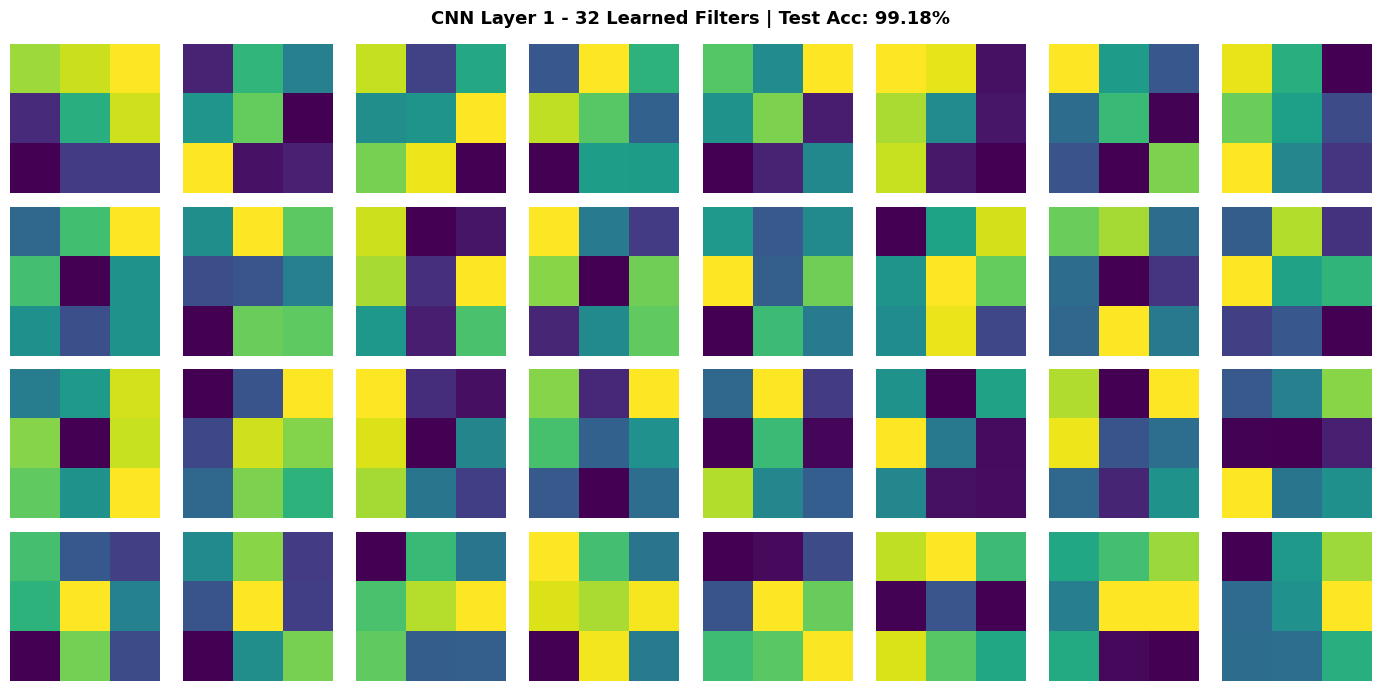


MLP vs CNN:
  MLP: 98.15%
  CNN: 99.18%


In [15]:
(X_tr, y_tr), (X_te, y_te) = mnist.load_data()
X_tr_c = X_tr.reshape(-1,28,28,1).astype('float32')/255.0
X_te_c = X_te.reshape(-1,28,28,1).astype('float32')/255.0
Y_tr_c = to_categorical(y_tr, 10); Y_te_c = to_categorical(y_te, 10)

cnn = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax'),
], name='CNN_MNIST')
cnn.summary()

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stop2 = callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
history_cnn = cnn.fit(X_tr_c, Y_tr_c, epochs=20, batch_size=256,
                       validation_split=0.1, callbacks=[early_stop2], verbose=1)

_, cnn_acc = cnn.evaluate(X_te_c, Y_te_c, verbose=0)
print(f"\n✅ CNN Test Accuracy: {cnn_acc*100:.2f}%")

# ── Visualize filters from first conv layer ──────────────────────────────────
filters = cnn.layers[0].get_weights()[0]
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.ravel()):
    if i < filters.shape[3]:
        ax.imshow(filters[:,:,0,i], cmap='viridis')
    ax.axis('off')
plt.suptitle(f'CNN Layer 1 - 32 Learned Filters | Test Acc: {cnn_acc*100:.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/03_cnn_filters.png', dpi=130, bbox_inches='tight'); plt.show()

print(f"\nMLP vs CNN:\n  MLP: {history_mlp.history['val_accuracy'][-1]*100:.2f}%\n  CNN: {cnn_acc*100:.2f}%")

### 3.5 LSTM & RNN - Time Series Prediction (Sine Wave)

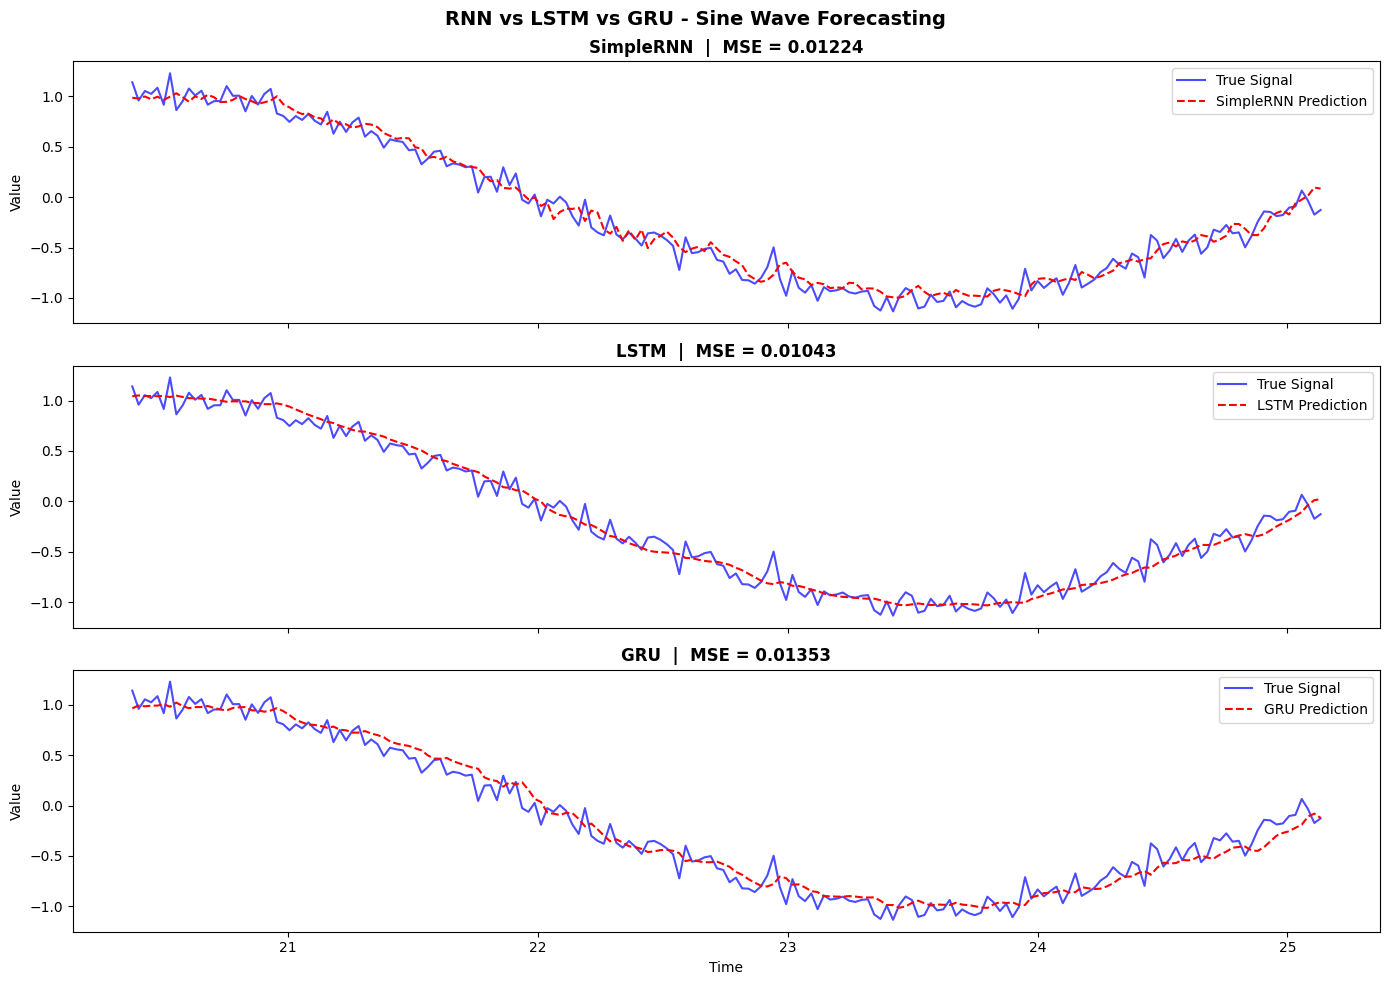

    Model Test MSE
SimpleRNN  0.01224
     LSTM  0.01043
      GRU  0.01353


In [16]:
# ── Generate sine wave data ──────────────────────────────────────────────────
t = np.linspace(0, 8*np.pi, 1000)
signal = np.sin(t) + 0.1*np.random.randn(len(t))

def make_sequences(data, seq_len=50):
    X_s, y_s = [], []
    for i in range(len(data)-seq_len):
        X_s.append(data[i:i+seq_len]); y_s.append(data[i+seq_len])
    return np.array(X_s)[..., None], np.array(y_s)

SEQ_LEN = 50
X_seq, y_seq = make_sequences(signal, SEQ_LEN)
split = int(0.8*len(X_seq))
X_str, X_ste = X_seq[:split], X_seq[split:]
y_str, y_ste = y_seq[:split], y_seq[split:]

models_seq = {}
for arch, lyr in [('SimpleRNN', layers.SimpleRNN(64)),
                  ('LSTM',      layers.LSTM(64)),
                  ('GRU',       layers.GRU(64))]:
    m = keras.Sequential([
        layers.Input(shape=(SEQ_LEN,1)),
        lyr,
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ], name=arch)
    m.compile(optimizer='adam', loss='mse')
    m.fit(X_str, y_str, epochs=10, batch_size=64, validation_split=0.1, verbose=0)
    models_seq[arch] = m

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
t_test = t[split+SEQ_LEN:]
for ax, (name, m) in zip(axes, models_seq.items()):
    preds = m.predict(X_ste, verbose=0).ravel()
    mse_v = mean_squared_error(y_ste, preds)
    ax.plot(t_test[:len(y_ste)], y_ste,  'b-',  lw=1.5, alpha=0.7, label='True Signal')
    ax.plot(t_test[:len(preds)], preds, 'r--', lw=1.5, label=f'{name} Prediction')
    ax.set_title(f'{name}  |  MSE = {mse_v:.5f}', fontweight='bold')
    ax.legend(loc='upper right'); ax.set_ylabel('Value')
axes[-1].set_xlabel('Time')
plt.suptitle('RNN vs LSTM vs GRU - Sine Wave Forecasting', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/03_lstm_rnn.png', dpi=130, bbox_inches='tight'); plt.show()

df_seq = pd.DataFrame([{'Model':k, 'Test MSE':f'{mean_squared_error(y_ste, v.predict(X_ste, verbose=0).ravel()):.5f}'}
                        for k,v in models_seq.items()])
print(df_seq.to_string(index=False))

### 3.6 Self-Organizing Maps (SOM)

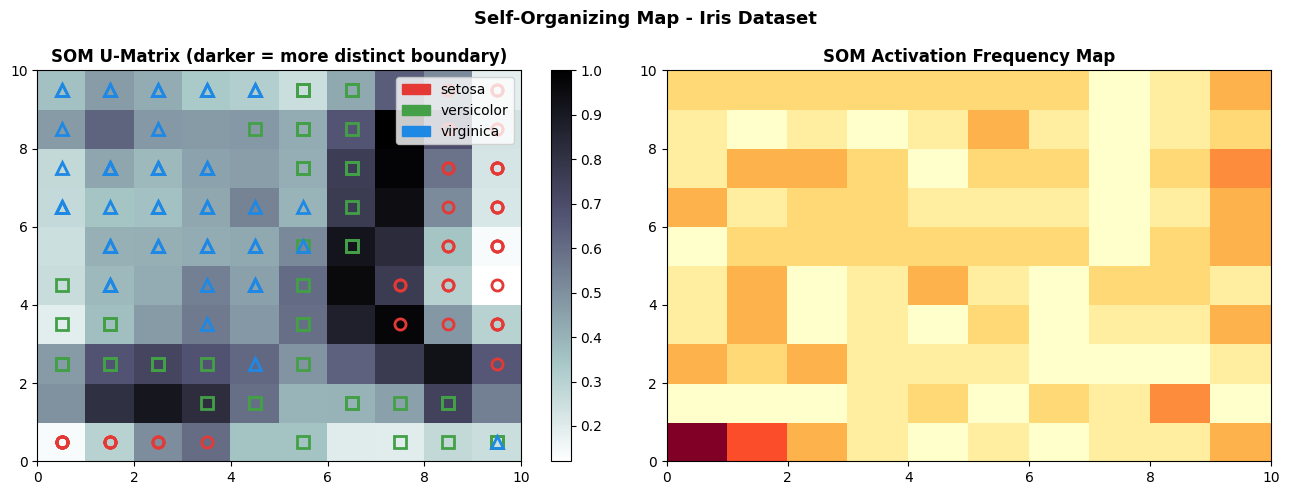

In [17]:
from minisom import MiniSom
iris = load_iris()
X_som = StandardScaler().fit_transform(iris.data)

som = MiniSom(10, 10, 4, sigma=1.5, learning_rate=0.5, random_seed=42)
som.random_weights_init(X_som)
som.train_random(X_som, 5000, verbose=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Distance map (U-matrix)
im = axes[0].pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(im, ax=axes[0])
markers = ['o', 's', '^']
colors  = ['#E53935','#43A047','#1E88E5']
for x_row, t in zip(X_som, iris.target):
    w = som.winner(x_row)
    axes[0].plot(w[0]+.5, w[1]+.5, markers[t], markerfacecolor='None',
                 markeredgecolor=colors[t], markersize=8, markeredgewidth=2)
axes[0].set_title('SOM U-Matrix (darker = more distinct boundary)', fontweight='bold')
patches = [mpatches.Patch(color=colors[i], label=iris.target_names[i]) for i in range(3)]
axes[0].legend(handles=patches, loc='upper right')

# Activation frequency
axes[1].pcolor(som.activation_response(X_som).T, cmap='YlOrRd')
axes[1].set_title('SOM Activation Frequency Map', fontweight='bold')
plt.suptitle('Self-Organizing Map - Iris Dataset', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/03_som.png', dpi=130, bbox_inches='tight'); plt.show()

---
## Module 4 - Deep Learning

**Deep Learning** uses many-layered networks to automatically learn hierarchical feature representations.

| Concept | Key Idea |
|---------|----------|
| Deep Neural Networks (DNN) | Many hidden layers, automatic feature extraction |
| Transfer Learning | Reuse pretrained weights for new tasks |
| GANs | Generator + Discriminator adversarial training |
| Attention Mechanisms | Selectively focus on relevant input parts |
| Deep RL | Combine deep networks with reward signals |
| Dropout | Regularization by randomly zeroing activations |
| Capsule Networks | Preserves spatial hierarchies in data |


### 4.1 Deep Neural Network Architecture - Visual Depth Analysis

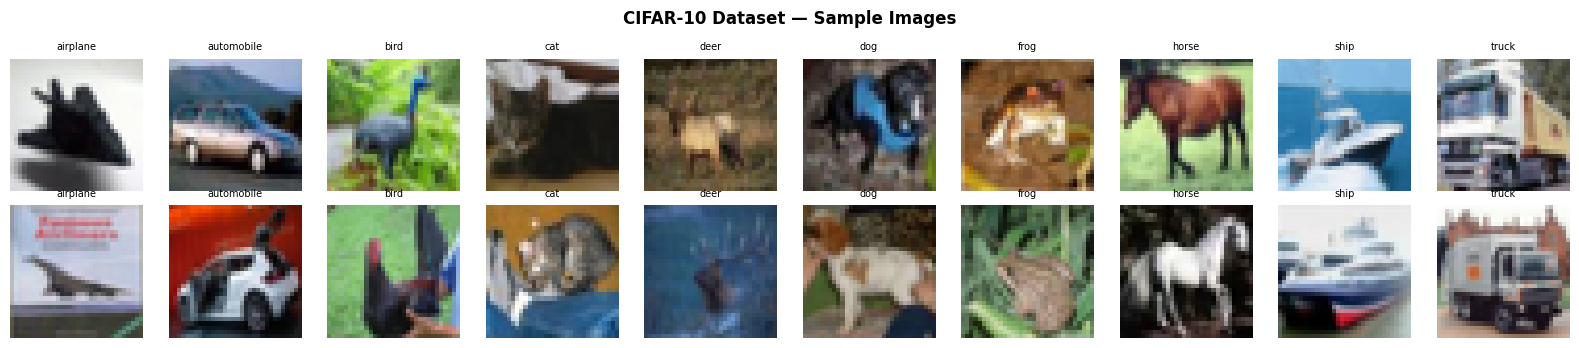

=== Effect of Network Depth on CIFAR-10 ===
 Depth  Params Test Acc
     1  395146   42.14%
     2  412170   42.62%
     4  446218   43.49%


In [19]:
from tensorflow.keras.datasets import cifar10
(Xc_tr, yc_tr), (Xc_te, yc_te) = cifar10.load_data()
Xc_tr = Xc_tr.astype('float32')/255.0; Xc_te = Xc_te.astype('float32')/255.0
Yc_tr = to_categorical(yc_tr, 10);      Yc_te = to_categorical(yc_te, 10)
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Show sample images
fig, axes = plt.subplots(2, 10, figsize=(16, 3.5))
for i in range(10):
    for j, (X_show, y_show) in enumerate([(Xc_tr, yc_tr), (Xc_te, yc_te)]):
        idx = np.where(y_show.ravel() == i)[0][0]
        axes[j, i].imshow(X_show[idx]); axes[j, i].axis('off')
        axes[j, i].set_title(class_names[i], fontsize=7)
plt.suptitle('CIFAR-10 Dataset — Sample Images', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_cifar10_samples.png', dpi=130, bbox_inches='tight')
plt.show()

# Flatten once up front
Xc_tr_flat = Xc_tr.reshape(len(Xc_tr), -1)   # (50000, 3072)
Xc_te_flat = Xc_te.reshape(len(Xc_te), -1)   # (10000, 3072)

def build_dnn(depth, width=128):
    m = keras.Sequential(name=f'DNN_depth{depth}')
    m.add(layers.Dense(width, activation='relu', input_shape=(3072,)))
    m.add(layers.BatchNormalization())
    m.add(layers.Dropout(0.3))
    for _ in range(depth - 1):
        m.add(layers.Dense(width, activation='relu'))
        m.add(layers.BatchNormalization())
        m.add(layers.Dropout(0.3))
    m.add(layers.Dense(10, activation='softmax'))
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

depth_results = []
for depth in [1, 2, 4]:
    m = build_dnn(depth)
    h = m.fit(Xc_tr_flat, Yc_tr, epochs=8, batch_size=512,
              validation_split=0.1, verbose=0)
    _, acc = m.evaluate(Xc_te_flat, Yc_te, verbose=0)
    depth_results.append({'Depth': depth, 'Params': m.count_params(),
                           'Test Acc': f'{acc*100:.2f}%'})

df_depth = pd.DataFrame(depth_results)
print("=== Effect of Network Depth on CIFAR-10 ===")
print(df_depth.to_string(index=False))

### 4.2 Transfer Learning - MobileNetV2 on CIFAR-10

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "TransferLearning_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 42s 364ms/step - accuracy: 0.6656 - loss: 1.0153 - val_accuracy: 0.8100 - val_loss: 0.5970
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8338 - loss: 0.4941 - val_accuracy: 0.8260 - val_loss: 0.5535
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8627 - loss: 0.4078 - val_accuracy: 0.8160 - val_loss: 0.5444
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8962 - loss: 0.2980 - val_accuracy: 0.8100 - val_loss: 0.5853
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9176 - loss: 0.2422 - val_accuracy: 0.8320 - val_loss: 0.5244
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9291 - loss: 0.2069 - val_accuracy: 0.8320 - val_loss: 0.5373
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9491 - loss: 0.1604 - val_accuracy: 0.8280 - val_loss: 0.5421
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9598 - loss: 0.1327 - val_accuracy: 0.8260 -

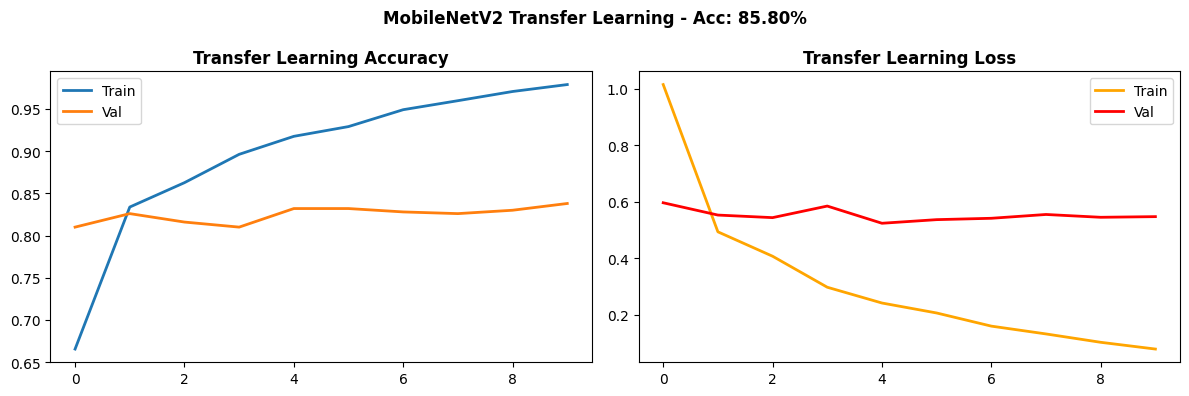

In [20]:
# ── Fine-tune MobileNetV2 pretrained on ImageNet ──────────────────────────
import tensorflow as tf
(Xc_tr, yc_tr), (Xc_te, yc_te) = cifar10.load_data()

# Resize to 96x96 for MobileNetV2 minimum input
def preprocess(X):
    X = tf.image.resize(X, [96, 96])
    return tf.keras.applications.mobilenet_v2.preprocess_input(X)

# Use small subset for speed
N_TRAIN, N_TEST = 5000, 1000
X_tl_tr = preprocess(Xc_tr[:N_TRAIN].astype('float32'))
X_tl_te = preprocess(Xc_te[:N_TEST].astype('float32'))
Y_tl_tr = to_categorical(yc_tr[:N_TRAIN], 10)
Y_tl_te = to_categorical(yc_te[:N_TEST],  10)

# Feature extraction (frozen base)
base = tf.keras.applications.MobileNetV2(input_shape=(96,96,3),
                                          include_top=False, weights='imagenet')
base.trainable = False

tl_model = keras.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax'),
], name='TransferLearning_MobileNetV2')

tl_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
tl_model.summary()

h_tl = tl_model.fit(X_tl_tr, Y_tl_tr, epochs=10, batch_size=64,
                     validation_split=0.1, verbose=1)
_, tl_acc = tl_model.evaluate(X_tl_te, Y_tl_te, verbose=0)
print(f"\n✅ Transfer Learning Test Accuracy: {tl_acc*100:.2f}% (trained on only {N_TRAIN} samples!)")

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(h_tl.history['accuracy'],     label='Train', lw=2)
axes[0].plot(h_tl.history['val_accuracy'], label='Val',   lw=2)
axes[0].set_title('Transfer Learning Accuracy', fontweight='bold'); axes[0].legend()
axes[1].plot(h_tl.history['loss'],     label='Train', lw=2, color='orange')
axes[1].plot(h_tl.history['val_loss'], label='Val',   lw=2, color='red')
axes[1].set_title('Transfer Learning Loss', fontweight='bold'); axes[1].legend()
plt.suptitle(f'MobileNetV2 Transfer Learning - Acc: {tl_acc*100:.2f}%', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/04_transfer_learning.png', dpi=130, bbox_inches='tight'); plt.show()

### 4.3 Generative Adversarial Network (GAN) - MNIST Digit Generation

Epoch 5/30 | D Loss: 0.5512 | G Loss: 0.9097
Epoch 10/30 | D Loss: 0.4485 | G Loss: 1.0115
Epoch 15/30 | D Loss: 0.3989 | G Loss: 1.1175
Epoch 20/30 | D Loss: 0.3705 | G Loss: 1.2203
Epoch 25/30 | D Loss: 0.3539 | G Loss: 1.3346
Epoch 30/30 | D Loss: 0.3434 | G Loss: 1.4813


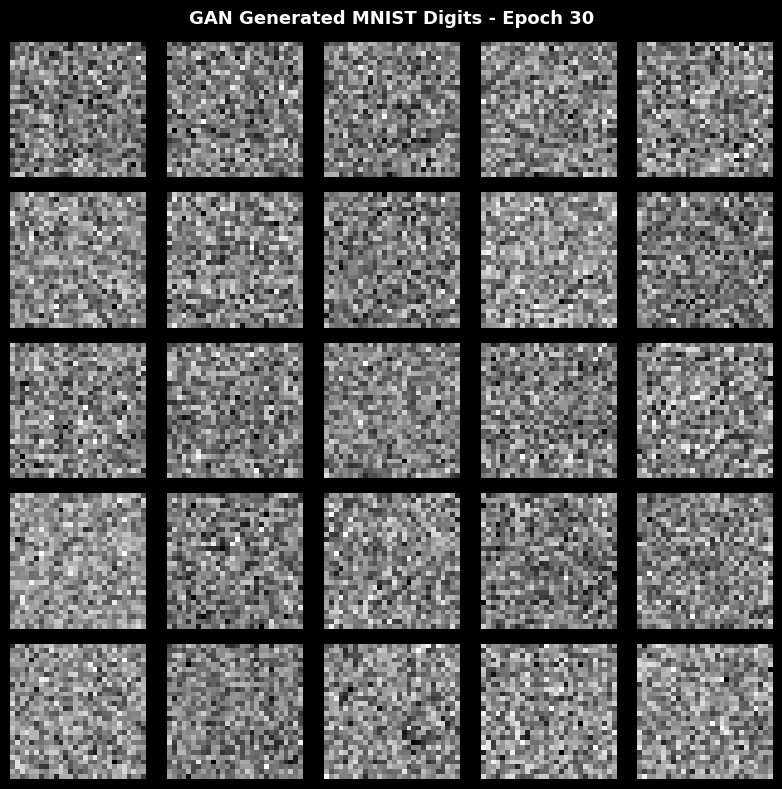

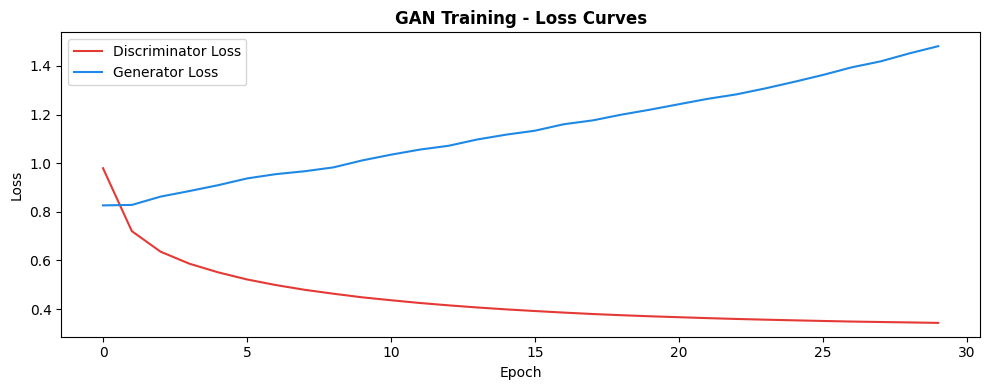

In [21]:
# ── Simple GAN on MNIST ──────────────────────────────────────────────────────
LATENT_DIM = 100
IMG_DIM     = 784

def build_generator(latent_dim):
    return keras.Sequential([
        layers.Dense(256, activation='relu',        input_shape=(latent_dim,)),
        layers.BatchNormalization(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(1024, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(IMG_DIM, activation='tanh'),
    ], name='Generator')

def build_discriminator():
    return keras.Sequential([
        layers.Dense(512,  activation=layers.LeakyReLU(0.2), input_shape=(IMG_DIM,)),
        layers.Dropout(0.4),
        layers.Dense(256,  activation=layers.LeakyReLU(0.2)),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid'),
    ], name='Discriminator')

generator     = build_generator(LATENT_DIM)
discriminator = build_discriminator()
discriminator.compile(optimizer=keras.optimizers.Adam(0.0002,0.5), loss='binary_crossentropy', metrics=['accuracy'])

# GAN
z = layers.Input(shape=(LATENT_DIM,))
img = generator(z)
discriminator.trainable = False
valid = discriminator(img)
gan = keras.Model(z, valid, name='GAN')
gan.compile(optimizer=keras.optimizers.Adam(0.0002,0.5), loss='binary_crossentropy')

# Training
(X_gan, _), _ = mnist.load_data()
X_gan = (X_gan.astype('float32') / 127.5) - 1.0
X_gan = X_gan.reshape(-1, 784)

BATCH, EPOCHS = 128, 30
d_losses, g_losses = [], []
sample_noise = np.random.normal(0, 1, (25, LATENT_DIM))

for epoch in range(EPOCHS):
    idx      = np.random.randint(0, X_gan.shape[0], BATCH)
    real_imgs = X_gan[idx]
    noise     = np.random.normal(0, 1, (BATCH, LATENT_DIM))
    fake_imgs = generator.predict(noise, verbose=0)
    real_lbl  = np.ones((BATCH, 1))  * 0.9  # label smoothing
    fake_lbl  = np.zeros((BATCH, 1)) * 0.1
    discriminator.trainable = True
    d_loss_r = discriminator.train_on_batch(real_imgs, real_lbl)
    d_loss_f = discriminator.train_on_batch(fake_imgs, fake_lbl)
    d_loss   = 0.5 * (d_loss_r[0] + d_loss_f[0])
    noise2   = np.random.normal(0, 1, (BATCH, LATENT_DIM))
    discriminator.trainable = False
    g_loss   = gan.train_on_batch(noise2, np.ones((BATCH,1)))
    d_losses.append(d_loss); g_losses.append(g_loss)
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | D Loss: {d_loss:.4f} | G Loss: {g_loss:.4f}")

# Generated images
generated = generator.predict(sample_noise, verbose=0)
generated = (generated + 1) / 2.0

fig, axes = plt.subplots(5, 5, figsize=(8,8))
fig.patch.set_facecolor('black')
for ax, img in zip(axes.ravel(), generated):
    ax.imshow(img.reshape(28,28), cmap='gray_r'); ax.axis('off')
plt.suptitle(f'GAN Generated MNIST Digits - Epoch {EPOCHS}', color='white',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/04_gan_generated.png', dpi=130,
                                 bbox_inches='tight', facecolor='black'); plt.show()

fig2, ax2 = plt.subplots(figsize=(10,4))
ax2.plot(d_losses, label='Discriminator Loss', lw=1.5, color='#E53935')
ax2.plot(g_losses, label='Generator Loss',     lw=1.5, color='#1E88E5')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.set_title('GAN Training - Loss Curves', fontweight='bold'); ax2.legend()
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/04_gan_loss.png', dpi=130, bbox_inches='tight'); plt.show()

### 4.4 Attention Mechanism - Scaled Dot-Product Attention

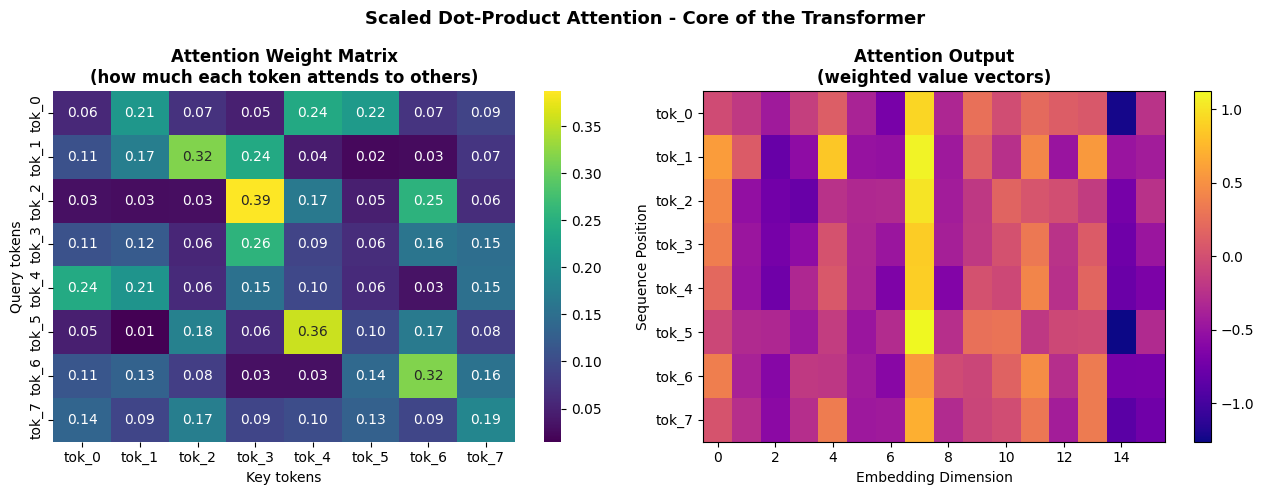

Query shape:   (8, 16)
Key shape:     (8, 16)
Value shape:   (8, 16)
Output shape:  (8, 16)
Attention max weights per query: [0.24  0.317 0.387 0.256 0.241 0.357 0.316 0.186]


In [22]:
def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores  = np.dot(Q, K.T) / np.sqrt(d_k)
    weights = np.exp(scores - scores.max(axis=-1, keepdims=True))
    weights = weights / weights.sum(axis=-1, keepdims=True)  # softmax
    output  = np.dot(weights, V)
    return output, weights

np.random.seed(0)
SEQ_LEN, D_MODEL = 8, 16
Q = np.random.randn(SEQ_LEN, D_MODEL)
K = np.random.randn(SEQ_LEN, D_MODEL)
V = np.random.randn(SEQ_LEN, D_MODEL)
output, attn_weights = scaled_dot_product_attention(Q, K, V)

tokens = [f'tok_{i}' for i in range(SEQ_LEN)]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(attn_weights, ax=axes[0], cmap='viridis', annot=True, fmt='.2f',
            xticklabels=tokens, yticklabels=tokens)
axes[0].set_title('Attention Weight Matrix\n(how much each token attends to others)',
                   fontweight='bold')
axes[0].set_xlabel('Key tokens'); axes[0].set_ylabel('Query tokens')

im = axes[1].imshow(output, aspect='auto', cmap='plasma')
axes[1].set_xlabel('Embedding Dimension'); axes[1].set_ylabel('Sequence Position')
axes[1].set_yticks(range(SEQ_LEN)); axes[1].set_yticklabels(tokens)
axes[1].set_title('Attention Output\n(weighted value vectors)', fontweight='bold')
plt.colorbar(im, ax=axes[1])

plt.suptitle('Scaled Dot-Product Attention - Core of the Transformer', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/04_attention.png', dpi=130, bbox_inches='tight'); plt.show()

print(f"Query shape:   {Q.shape}")
print(f"Key shape:     {K.shape}")
print(f"Value shape:   {V.shape}")
print(f"Output shape:  {output.shape}")
print(f"Attention max weights per query: {attn_weights.max(axis=1).round(3)}")

### 4.5 Dropout - Regularization Effect

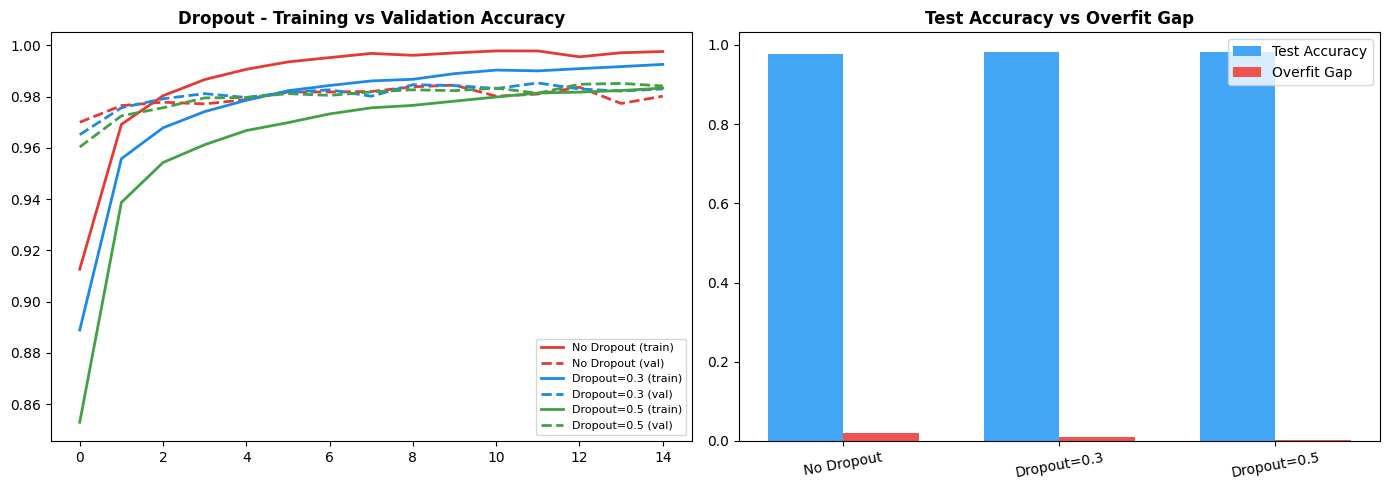

      Model Test Acc Overfit Gap
 No Dropout    0.977      0.0210
Dropout=0.3    0.983      0.0098
Dropout=0.5    0.982      0.0012


In [23]:
# ── Compare no dropout vs dropout on MNIST ───────────────────────────────────
(X_tr, y_tr), (X_te, y_te) = mnist.load_data()
X_tr_f = X_tr.reshape(-1,784).astype('float32')/255.0
X_te_f = X_te.reshape(-1,784).astype('float32')/255.0
Y_tr_c = to_categorical(y_tr,10); Y_te_c = to_categorical(y_te,10)

results_drop = {}
for name, drop_rate in [('No Dropout', 0.0), ('Dropout=0.3', 0.3), ('Dropout=0.5', 0.5)]:
    m = keras.Sequential([
        layers.Dense(512, activation='relu', input_shape=(784,)),
        layers.Dropout(drop_rate),
        layers.Dense(256, activation='relu'),
        layers.Dropout(drop_rate),
        layers.Dense(10, activation='softmax'),
    ])
    m.compile('adam','categorical_crossentropy',metrics=['accuracy'])
    h = m.fit(X_tr_f, Y_tr_c, epochs=15, batch_size=256, validation_split=0.1, verbose=0)
    _, te_acc = m.evaluate(X_te_f, Y_te_c, verbose=0)
    results_drop[name] = (h.history['accuracy'], h.history['val_accuracy'], te_acc)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
colors_d = ['#E53935','#1E88E5','#43A047']
for (name, (tr_h, vl_h, te_a)), col in zip(results_drop.items(), colors_d):
    axes[0].plot(tr_h, lw=2, color=col, label=f'{name} (train)')
    axes[0].plot(vl_h, lw=2, color=col, linestyle='--', label=f'{name} (val)')
axes[0].set_title('Dropout - Training vs Validation Accuracy', fontweight='bold'); axes[0].legend(fontsize=8)

names_d  = list(results_drop.keys())
te_accs  = [v[2] for v in results_drop.values()]
overfit  = [max(v[0]) - v[2] for v in results_drop.values()]
x_pos = np.arange(len(names_d)); width=0.35
axes[1].bar(x_pos-width/2, te_accs, width, label='Test Accuracy',   color='#42A5F5')
axes[1].bar(x_pos+width/2, overfit, width, label='Overfit Gap', color='#EF5350')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(names_d, rotation=10)
axes[1].set_title('Test Accuracy vs Overfit Gap', fontweight='bold'); axes[1].legend()
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/04_dropout.png', dpi=130, bbox_inches='tight'); plt.show()

df_drop = pd.DataFrame({'Model':names_d,'Test Acc':[f'{a:.3f}' for a in te_accs],
                         'Overfit Gap':[f'{g:.4f}' for g in overfit]})
print(df_drop.to_string(index=False))

### 4.6 Deep Reinforcement Learning - Q-Learning on GridWorld

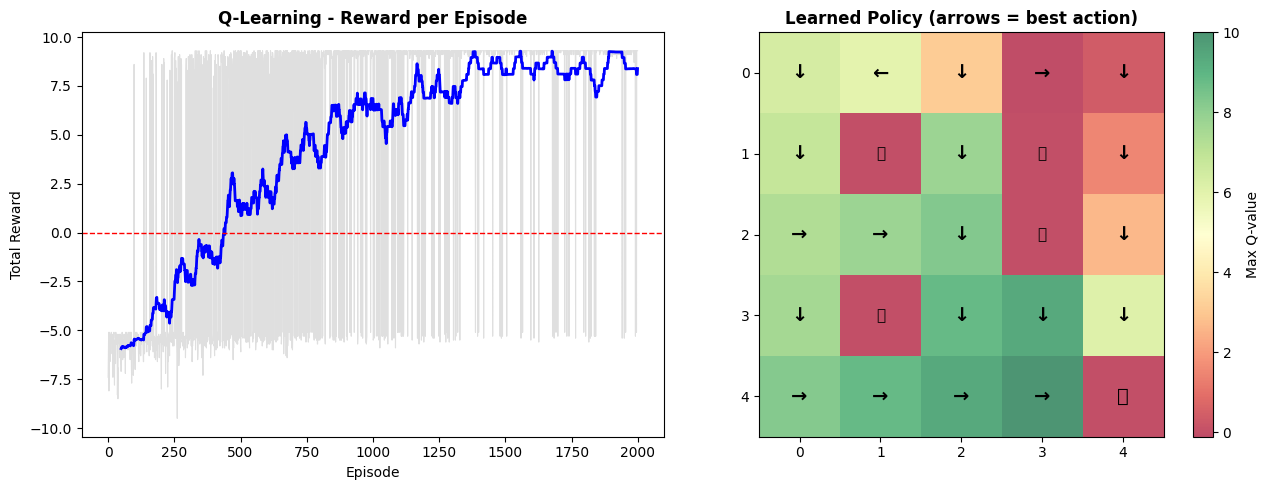

Final avg reward (last 100 episodes): 8.52


In [24]:
# ── Tabular Q-Learning on a simple GridWorld ─────────────────────────────────
class GridWorld:
    def __init__(self, size=5):
        self.size = size
        self.goal  = (size-1, size-1)
        self.traps = [(1,1),(2,3),(3,1),(1,3)]
        self.reset()
    def reset(self):
        self.pos = (0,0); return self._state()
    def _state(self): return self.pos[0]*self.size + self.pos[1]
    def step(self, action):
        moves = {0:(-1,0),1:(1,0),2:(0,-1),3:(0,1)}  # up,down,left,right
        dr, dc = moves[action]
        nr = max(0, min(self.size-1, self.pos[0]+dr))
        nc = max(0, min(self.size-1, self.pos[1]+dc))
        self.pos = (nr, nc)
        if self.pos == self.goal:   return self._state(), +10, True
        if self.pos in self.traps:  return self._state(), -5,  True
        return self._state(), -0.1, False

n_states, n_actions = 25, 4
Q = np.zeros((n_states, n_actions))
env = GridWorld(5)
eps, alpha, gamma = 1.0, 0.1, 0.95
episode_rewards = []

for ep in range(2000):
    state = env.reset(); total_r = 0; done = False
    while not done:
        if np.random.rand() < eps:
            action = np.random.randint(n_actions)
        else:
            action = np.argmax(Q[state])
        next_state, reward, done = env.step(action)
        Q[state, action] += alpha * (reward + gamma*np.max(Q[next_state]) - Q[state,action])
        state = next_state; total_r += reward
    episode_rewards.append(total_r)
    if eps > 0.05: eps *= 0.998

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Smoothed reward curve
window = 50
smoothed = np.convolve(episode_rewards, np.ones(window)/window, 'valid')
axes[0].plot(episode_rewards, alpha=0.25, color='gray', lw=0.8)
axes[0].plot(range(window-1, len(episode_rewards)), smoothed, 'b-', lw=2)
axes[0].axhline(0, color='red', linestyle='--', lw=1)
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Total Reward')
axes[0].set_title('Q-Learning - Reward per Episode', fontweight='bold')

# Learned policy grid
policy_arrows = {0:'↑',1:'↓',2:'←',3:'→'}
grid = np.max(Q, axis=1).reshape(5,5)
im = axes[1].imshow(grid, cmap='RdYlGn', alpha=0.7)
plt.colorbar(im, ax=axes[1], label='Max Q-value')
for r in range(5):
    for c in range(5):
        s = r*5+c
        if (r,c) == (4,4):    axes[1].text(c,r,'🏆',ha='center',va='center',fontsize=14)
        elif (r,c) in [(1,1),(2,3),(3,1),(1,3)]:
                              axes[1].text(c,r,'💣',ha='center',va='center',fontsize=11)
        else:                 axes[1].text(c,r,policy_arrows[np.argmax(Q[s])],
                                           ha='center',va='center',fontsize=14,fontweight='bold')
axes[1].set_title('Learned Policy (arrows = best action)', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/04_qlearning.png', dpi=130, bbox_inches='tight'); plt.show()
print(f"Final avg reward (last 100 episodes): {np.mean(episode_rewards[-100:]):.2f}")

### 4.x Capsule Networks — Routing by Agreement on MNIST
Capsule Networks (Sabour et al., 2017) replace scalar activations with
vectors (capsules) that encode both the presence and pose of a feature.
Dynamic routing-by-agreement replaces max-pooling.

Model: "SimpleCapsNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 64)     │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 128)      │       663,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 576, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 576, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digit_caps (CapsuleLayer)       │ (None, 10, 16)         │       737,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capsule_length (Lambda)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,406,208 (5.36 MB)

 Trainable params: 1,406,208 (5.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - accuracy: 0.1104 - loss: 0.1000 - val_accuracy: 0.1210 - val_loss: 0.1000
Epoch 2/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1153 - loss: 0.1000 - val_accuracy: 0.1240 - val_loss: 0.1000
Epoch 3/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1281 - loss: 0.1000 - val_accuracy: 0.1380 - val_loss: 0.1000
Epoch 4/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1353 - loss: 0.0999 - val_accuracy: 0.0910 - val_loss: 0.1009
Epoch 5/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7257 - loss: 0.0444 - val_accuracy: 0.9410 - val_loss: 0.0154
Epoch 6/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9560 - loss: 0.0124 - val_accuracy: 0.9640 - val_loss: 0.0093
Epoch 7/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9739 - loss: 0.0081 - val_accuracy: 0.9690 - val_loss: 0.0077
Epoch 8/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9819 - loss: 0.0062 - val_accuracy: 0.9720 - val_los

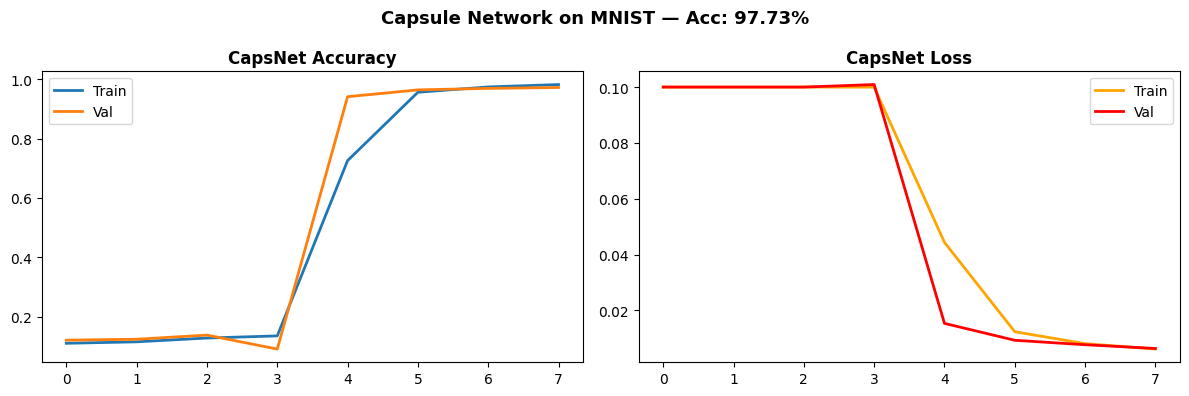

In [37]:
# ── Simplified CapsNet on MNIST ───────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, models

# ── Squash activation (capsule non-linearity) ─────────────────────────────────
def squash(vectors, axis=-1):
    s_sq_norm = tf.reduce_sum(tf.square(vectors), axis=axis, keepdims=True)
    scale     = s_sq_norm / (1 + s_sq_norm) / tf.sqrt(s_sq_norm + 1e-8)
    return scale * vectors

class CapsuleLayer(layers.Layer):
    def __init__(self, n_caps, caps_dim, routings=3, **kwargs):
        super().__init__(**kwargs)
        self.n_caps  = n_caps
        self.caps_dim = caps_dim
        self.routings = routings

    def build(self, input_shape):
        self.n_in_caps  = input_shape[1]
        self.in_caps_dim = input_shape[2]
        self.W = self.add_weight(
            shape=(1, self.n_in_caps, self.n_caps, self.caps_dim, self.in_caps_dim),
            initializer='glorot_uniform', trainable=True, name='W')

    def call(self, inputs):
        batch = tf.shape(inputs)[0]
        inputs_hat = tf.squeeze(
            tf.matmul(tf.tile(self.W, [batch,1,1,1,1]),
                      tf.expand_dims(tf.expand_dims(inputs, 2), -1)),
            axis=-1)                    # (batch, n_in, n_caps, caps_dim)
        b = tf.zeros_like(inputs_hat[:,:,:,0])   # routing logits
        for i in range(self.routings):
            c = tf.nn.softmax(b, axis=2)
            s = tf.reduce_sum(tf.multiply(tf.expand_dims(c,-1), inputs_hat), axis=1)
            v = squash(s)
            if i < self.routings - 1:
                b += tf.reduce_sum(tf.multiply(
                    tf.expand_dims(v, 1), inputs_hat), axis=-1)
        return v  # (batch, n_caps, caps_dim)

def capsule_length(x):
    return tf.sqrt(tf.reduce_sum(tf.square(x), axis=-1) + 1e-8)

# ── Build model ───────────────────────────────────────────────────────────────
inp_c  = layers.Input(shape=(28, 28, 1))
conv1  = layers.Conv2D(64, 9, activation='relu', padding='valid')(inp_c)
conv2  = layers.Conv2D(128, 9, strides=2, activation='relu', padding='valid')(conv1)

# Reshape to primary capsules
n_primary, primary_dim = 32, 8
primary_shape = conv2.shape[1] * conv2.shape[2] * (128 // primary_dim)
primary = layers.Reshape((primary_shape, primary_dim))(conv2)
primary = layers.Lambda(squash)(primary)

# Digit capsules
digit_caps = CapsuleLayer(10, 16, routings=3, name='digit_caps')(primary)
out_caps   = layers.Lambda(capsule_length, name='capsule_length')(digit_caps)

capsnet = models.Model(inp_c, out_caps, name='SimpleCapsNet')
capsnet.compile(optimizer=keras.optimizers.Adam(0.001),
                loss='mse', metrics=['accuracy'])
capsnet.summary()

# ── Load & train ──────────────────────────────────────────────────────────────
(X_tr_c, y_tr_c), (X_te_c, y_te_c) = mnist.load_data()
X_tr_c = X_tr_c.reshape(-1,28,28,1).astype('float32')/255.0
X_te_c = X_te_c.reshape(-1,28,28,1).astype('float32')/255.0
Y_tr_c = to_categorical(y_tr_c, 10)
Y_te_c = to_categorical(y_te_c, 10)

# Use a subset for speed
N = 10000
h_caps = capsnet.fit(X_tr_c[:N], Y_tr_c[:N], epochs=8, batch_size=128,
                      validation_split=0.1, verbose=1)
_, caps_acc = capsnet.evaluate(X_te_c, Y_te_c, verbose=0)
print(f"\n✅ CapsNet Test Accuracy: {caps_acc*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h_caps.history['accuracy'],     lw=2, label='Train')
axes[0].plot(h_caps.history['val_accuracy'], lw=2, label='Val')
axes[0].set_title('CapsNet Accuracy', fontweight='bold'); axes[0].legend()
axes[1].plot(h_caps.history['loss'],     lw=2, color='orange', label='Train')
axes[1].plot(h_caps.history['val_loss'], lw=2, color='red',    label='Val')
axes[1].set_title('CapsNet Loss', fontweight='bold'); axes[1].legend()
plt.suptitle(f'Capsule Network on MNIST — Acc: {caps_acc*100:.2f}%', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04x_capsnet.png', dpi=130, bbox_inches='tight')
plt.show()

### Deep Belief Networks (DBNs) — Stacked RBMs on MNIST
A Deep Belief Network stacks Restricted Boltzmann Machines (RBMs).
Each RBM learns a layer of features unsupervised; a final classifier
is added on top. This cell uses sklearn's BernoulliRBM.

✅ DBN (RBM×2 + LR) Test Accuracy: 93.85%
   Baseline (raw pixels + LR): 90.54%


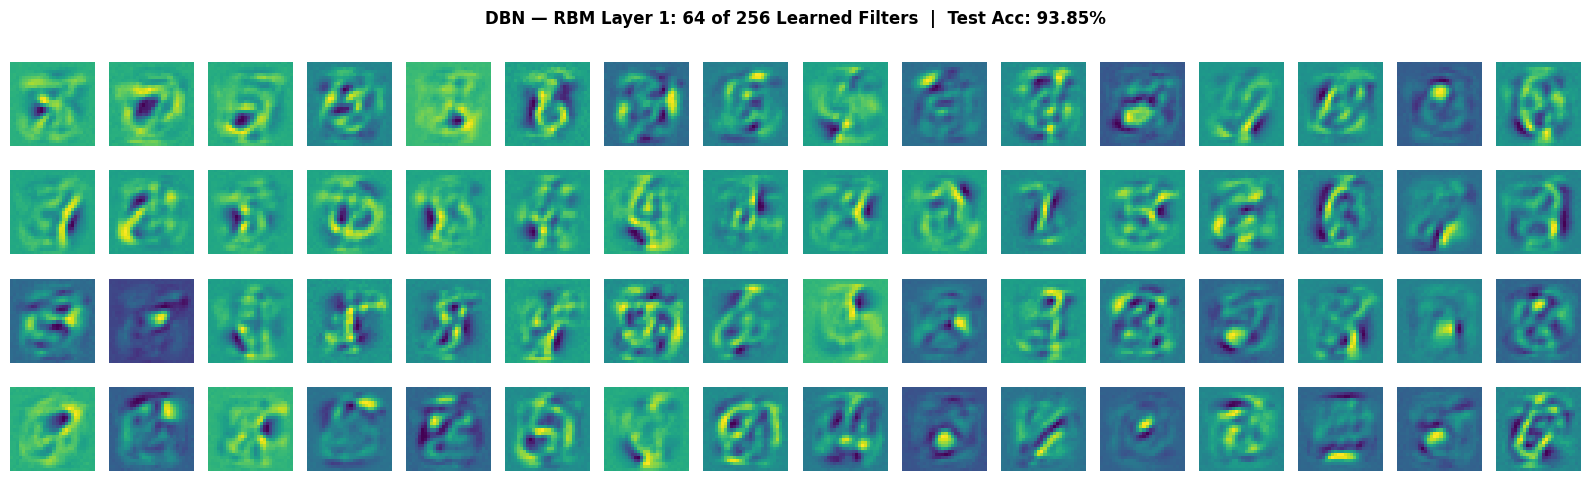

           Model Test Accuracy            Feature Source
 Raw Pixels + LR        90.54%            Raw 784 pixels
DBN (RBM×2 + LR)        93.85% Unsupervised RBM features


In [38]:
# ── DBN: Stacked RBMs + Logistic Regression ───────────────────────────────────
from sklearn.neural_network import BernoulliRBM
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

(X_tr_d, y_tr_d), (X_te_d, y_te_d) = mnist.load_data()
X_tr_d = X_tr_d.reshape(-1, 784).astype('float32') / 255.0
X_te_d = X_te_d.reshape(-1, 784).astype('float32') / 255.0

# Subset for speed
N_DBN = 10000
X_tr_sub = X_tr_d[:N_DBN]; y_tr_sub = y_tr_d[:N_DBN]

# ── Layer 1 RBM ───────────────────────────────────────────────────────────────
rbm1 = BernoulliRBM(n_components=256, learning_rate=0.01,
                     n_iter=15, random_state=42, verbose=0)
# ── Layer 2 RBM ───────────────────────────────────────────────────────────────
rbm2 = BernoulliRBM(n_components=128, learning_rate=0.01,
                     n_iter=15, random_state=42, verbose=0)
# ── Classifier ────────────────────────────────────────────────────────────────
logistic = LogisticRegression(max_iter=200, solver='saga', random_state=42)

dbn = Pipeline([('rbm1', rbm1), ('rbm2', rbm2), ('logistic', logistic)])
dbn.fit(X_tr_sub, y_tr_sub)
dbn_acc = accuracy_score(y_te_d, dbn.predict(X_te_d))
print(f"✅ DBN (RBM×2 + LR) Test Accuracy: {dbn_acc*100:.2f}%")

# Baseline: raw pixels + logistic
lr_raw = LogisticRegression(max_iter=200, solver='saga', random_state=42)
lr_raw.fit(X_tr_sub, y_tr_sub)
raw_acc = accuracy_score(y_te_d, lr_raw.predict(X_te_d))
print(f"   Baseline (raw pixels + LR): {raw_acc*100:.2f}%")

# ── Visualize learned RBM filters ─────────────────────────────────────────────
fig, axes = plt.subplots(4, 16, figsize=(16, 5))
fig.suptitle(f'DBN — RBM Layer 1: 64 of 256 Learned Filters  |  Test Acc: {dbn_acc*100:.2f}%',
             fontsize=12, fontweight='bold')
for ax, component in zip(axes.ravel(), rbm1.components_[:64]):
    ax.imshow(component.reshape(28, 28), cmap='viridis', interpolation='nearest')
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04x_dbn_filters.png', dpi=130, bbox_inches='tight')
plt.show()

df_dbn = pd.DataFrame({'Model':          ['Raw Pixels + LR', 'DBN (RBM×2 + LR)'],
                        'Test Accuracy':  [f'{raw_acc*100:.2f}%', f'{dbn_acc*100:.2f}%'],
                        'Feature Source': ['Raw 784 pixels', 'Unsupervised RBM features']})
print(df_dbn.to_string(index=False))

---
## Module 5 - Generative AI (Innermost Ring)

**Generative AI** can produce new content (text, images, code, audio) indistinguishable from human-created artifacts.

| Topic | Description |
|-------|-------------|
| Language Modeling | Predicting the next token in a sequence |
| Transformer Architecture | Self-attention-based seq2seq architecture |
| Self-Attention | Each token attends to all others |
| Natural Language Understanding | Classification, NER, intent detection |
| Text Generation | Autoregressive decoding from LLMs |
| Summarization | Condensing long text to key points |
| Dialogue Systems | Multi-turn conversational AI |


### 5.1 Language Modeling - N-Gram Model

Corpus tokens: 5,790

3-gram generation:
  alice was so much into the loveliest garden you ever eat a little bottle on it in large letters it was the fan and a sad tale said the lory positively refused

4-gram generation:
  alice was


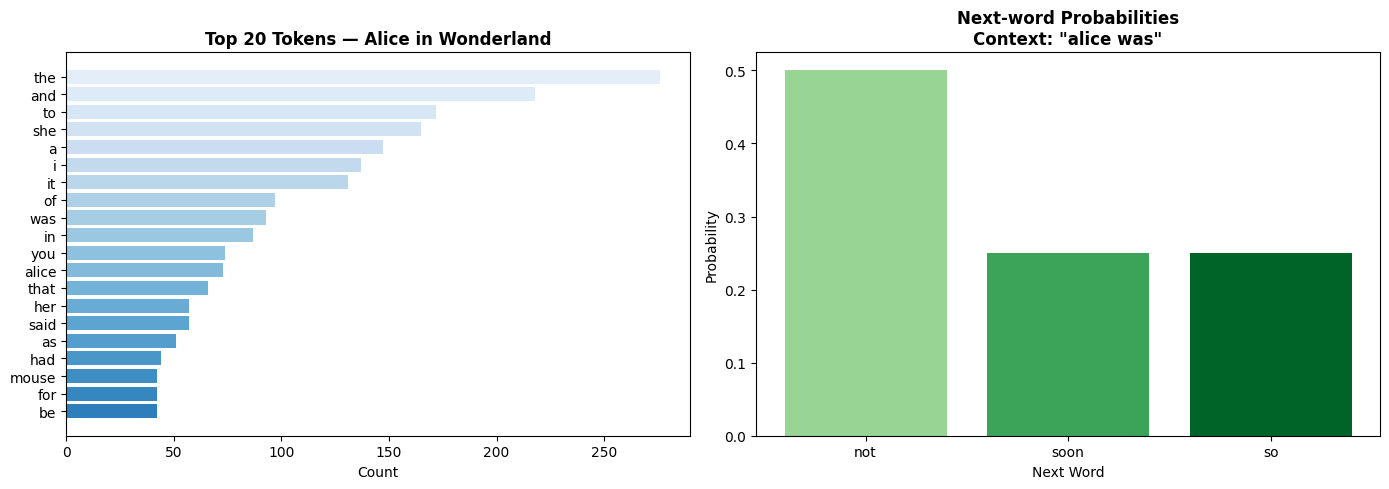

In [26]:
import re
from collections import defaultdict, Counter

subprocess.run(['wget', '-q', '-O', '/content/alice.txt',
    'https://www.gutenberg.org/files/11/11-0.txt'], check=True)

with open('/content/alice.txt', 'r', encoding='utf-8', errors='ignore') as f:
    raw = f.read()[5000:35000]

tokens = re.findall(r"[a-z']+", raw.lower())
print(f"Corpus tokens: {len(tokens):,}")

class NGramLM:
    def __init__(self, n=3):
        self.n = n
        self.model = defaultdict(Counter)
    def train(self, tokens):
        for i in range(len(tokens)-self.n):
            ctx   = tuple(tokens[i:i+self.n-1])
            next_ = tokens[i+self.n-1]
            self.model[ctx][next_] += 1
    def predict_next(self, context, top_k=5):
        ctx = tuple(context[-(self.n-1):])
        if ctx not in self.model: return []
        total = sum(self.model[ctx].values())
        return [(w, c/total) for w,c in self.model[ctx].most_common(top_k)]
    def generate(self, seed, n_words=30):
        result = list(seed)
        for _ in range(n_words):
            preds = self.predict_next(result)
            if not preds: break
            words, probs = zip(*preds)
            probs = np.array(probs, dtype=np.float64)
            probs = probs / probs.sum()          # ← re-normalize to fix float drift
            result.append(np.random.choice(words, p=probs))
        return ' '.join(result)

lm3 = NGramLM(n=3); lm3.train(tokens)
lm4 = NGramLM(n=4); lm4.train(tokens)

seed = ['alice', 'was']
gen3 = lm3.generate(seed, 30)
gen4 = lm4.generate(seed, 30)
print(f"\n3-gram generation:\n  {gen3}")
print(f"\n4-gram generation:\n  {gen4}")

freq = Counter(tokens)
top20 = freq.most_common(20)
words20, counts20 = zip(*top20)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].barh(list(words20)[::-1], list(counts20)[::-1],
             color=plt.cm.Blues_r(np.linspace(0.3,0.9,20)))
axes[0].set_title('Top 20 Tokens — Alice in Wonderland', fontweight='bold')
axes[0].set_xlabel('Count')

preds = lm3.predict_next(seed, top_k=8)
if preds:
    ws, ps = zip(*preds)
    axes[1].bar(ws, ps, color=plt.cm.Greens(np.linspace(0.4,0.9,len(ws))))
    axes[1].set_title(f'Next-word Probabilities\nContext: "{" ".join(seed)}"', fontweight='bold')
    axes[1].set_xlabel('Next Word'); axes[1].set_ylabel('Probability')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_ngram_lm.png', dpi=130, bbox_inches='tight')
plt.show()

### 5.2 Transformer Architecture - Build from Scratch

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "Transformer_IMDb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 200, 64)        │       652,800 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 200, 64)        │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 20)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687,593 (2.62 MB)

 Trainable params: 687,593 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.7897 - loss: 0.4244 - val_accuracy: 0.8840 - val_loss: 0.2883
Epoch 2/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9099 - loss: 0.2272 - val_accuracy: 0.8656 - val_loss: 0.3326
Epoch 3/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9394 - loss: 0.1636 - val_accuracy: 0.8720 - val_loss: 0.3361
Epoch 4/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9571 - loss: 0.1216 - val_accuracy: 0.8648 - val_loss: 0.4127
Epoch 5/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9679 - loss: 0.0941 - val_accuracy: 0.8628 - val_loss: 0.4705
Epoch 6/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9754 - loss: 0.0742 - val_accuracy: 0.8560 - val_loss: 0.5572
Epoch 7/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9780 - loss: 0.0611 - val_accuracy: 0.8620 - val_loss: 0.5941
Epoch 8/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9824 - loss: 0.0457 - val_accuracy: 0.8612 -

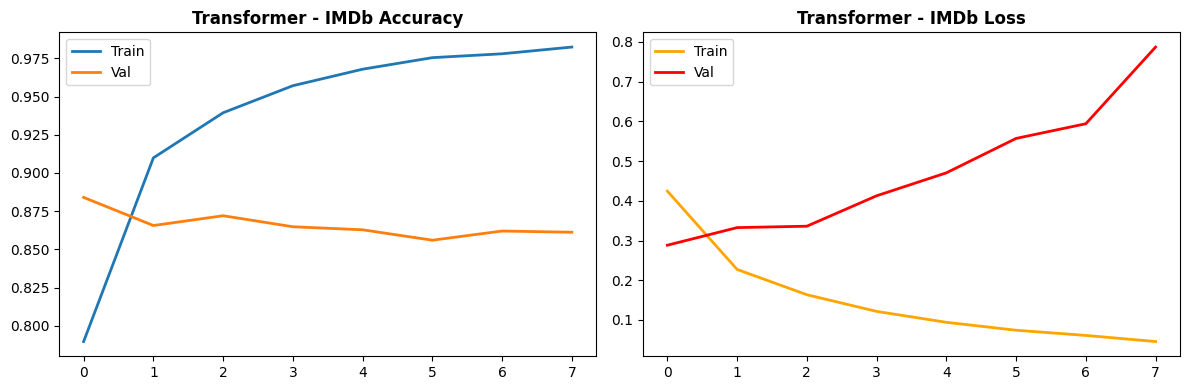

In [27]:
# ── Minimal Transformer encoder in Keras/TF ──────────────────────────────────
class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.embed_dim = embed_dim
        assert embed_dim % num_heads == 0
        self.depth = embed_dim // num_heads
        self.Wq = layers.Dense(embed_dim)
        self.Wk = layers.Dense(embed_dim)
        self.Wv = layers.Dense(embed_dim)
        self.dense = layers.Dense(embed_dim)
    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0,2,1,3])
    def call(self, x):
        bs = tf.shape(x)[0]
        Q  = self.split_heads(self.Wq(x), bs)
        K  = self.split_heads(self.Wk(x), bs)
        V  = self.split_heads(self.Wv(x), bs)
        scale  = tf.cast(self.depth, tf.float32) ** -0.5
        attn   = tf.nn.softmax(tf.matmul(Q, K, transpose_b=True) * scale, axis=-1)
        out    = tf.matmul(attn, V)
        out    = tf.transpose(out, [0,2,1,3])
        out    = tf.reshape(out, (bs, -1, self.embed_dim))
        return self.dense(out)

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ff    = keras.Sequential([layers.Dense(ff_dim,'relu'), layers.Dense(embed_dim)])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(rate)
        self.drop2 = layers.Dropout(rate)
    def call(self, x, training=False):
        attn_out = self.drop1(self.attn(x), training=training)
        x = self.norm1(x + attn_out)
        ff_out = self.drop2(self.ff(x), training=training)
        return self.norm2(x + ff_out)

class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = layers.Embedding(vocab_size, embed_dim)
        self.pos_emb   = layers.Embedding(maxlen, embed_dim)
    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        return self.token_emb(x) + self.pos_emb(positions)

# ── Train for sentiment classification (IMDb) ─────────────────────────────────
VOCAB_SIZE, MAXLEN, EMBED_DIM, NUM_HEADS, FF_DIM = 10000, 200, 64, 4, 128
(X_im_tr, y_im_tr), (X_im_te, y_im_te) = imdb.load_data(num_words=VOCAB_SIZE)
X_im_tr = keras.preprocessing.sequence.pad_sequences(X_im_tr, maxlen=MAXLEN)
X_im_te = keras.preprocessing.sequence.pad_sequences(X_im_te, maxlen=MAXLEN)

inp = layers.Input(shape=(MAXLEN,))
x = TokenAndPositionEmbedding(MAXLEN, VOCAB_SIZE, EMBED_DIM)(inp)
x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(20, activation='relu')(x)
x = layers.Dropout(0.1)(x)
out = layers.Dense(1, activation='sigmoid')(x)
transformer_model = keras.Model(inp, out, name='Transformer_IMDb')
transformer_model.summary()

transformer_model.compile('adam', 'binary_crossentropy', metrics=['accuracy'])
h_tf = transformer_model.fit(X_im_tr, y_im_tr, epochs=8, batch_size=64,
                               validation_split=0.1, verbose=1)
_, tf_acc = transformer_model.evaluate(X_im_te, y_im_te, verbose=0)
print(f"\n✅ Transformer IMDb Sentiment Accuracy: {tf_acc*100:.2f}%")

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(h_tf.history['accuracy'],     lw=2, label='Train')
axes[0].plot(h_tf.history['val_accuracy'], lw=2, label='Val')
axes[0].set_title('Transformer - IMDb Accuracy', fontweight='bold'); axes[0].legend()
axes[1].plot(h_tf.history['loss'],     lw=2, color='orange', label='Train')
axes[1].plot(h_tf.history['val_loss'], lw=2, color='red', label='Val')
axes[1].set_title('Transformer - IMDb Loss', fontweight='bold'); axes[1].legend()
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/05_transformer.png', dpi=130, bbox_inches='tight'); plt.show()

### 5.3 Pretrained Transformers - HuggingFace: NLU, Generation & Summarization

In [30]:
from transformers import pipeline, AutoTokenizer

# ── 1. Sentiment Analysis (NLU) ───────────────────────────────────────────────
print("=== 1. Sentiment Analysis ===")
sentiment = pipeline("sentiment-analysis",
                     model="distilbert-base-uncased-finetuned-sst-2-english")
texts_sent = [
    "Artificial Intelligence is transforming every industry.",
    "This neural network converges too slowly - frustrating!",
    "The transformer architecture is an elegant and powerful design.",
    "Overfitting ruined my model completely.",
]
sent_results = sentiment(texts_sent)
df_sent = pd.DataFrame([{'Text': t[:55]+'...', 'Label': r['label'],
                          'Score': f"{r['score']:.3f}"}
                         for t,r in zip(texts_sent, sent_results)])
print(df_sent.to_string(index=False))

# ── 2. Zero-shot Classification ───────────────────────────────────────────────
print("\n=== 2. Zero-Shot Classification ===")
zsc = pipeline("zero-shot-classification",
               model="facebook/bart-large-mnli")
text_zsc = "This paper proposes a novel quantum-resistant encryption algorithm for IoT devices."
labels   = ["cybersecurity","machine learning","quantum computing","robotics","healthcare"]
res_zsc  = zsc(text_zsc, candidate_labels=labels)
df_zsc   = pd.DataFrame({'Label': res_zsc['labels'],
                          'Score': [f'{s:.3f}' for s in res_zsc['scores']]})
print(f"Input: '{text_zsc[:60]}...'")
print(df_zsc.to_string(index=False))

# ── 3. Summarization (direct model call — pipeline task removed in this transformers version) ──
print("\n=== 3. Summarization ===")
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

sum_tokenizer = AutoTokenizer.from_pretrained("facebook/bart-large-cnn")
sum_model     = AutoModelForSeq2SeqLM.from_pretrained("facebook/bart-large-cnn")

long_text = (
    "Deep learning has revolutionized AI by enabling machines to learn hierarchical "
    "representations from raw data. Unlike traditional ML that requires manual feature "
    "engineering, deep learning models automatically extract features at multiple levels. "
    "This has led to breakthroughs in computer vision, NLP, speech recognition, and drug "
    "discovery. The transformer architecture replaced recurrence with self-attention, enabling "
    "parallel training on massive datasets and giving rise to LLMs like GPT and BERT."
)

inputs     = sum_tokenizer(long_text, return_tensors="pt", max_length=512, truncation=True)
sum_ids    = sum_model.generate(inputs["input_ids"], max_length=60, min_length=20,
                                 length_penalty=2.0, num_beams=4, early_stopping=True)
summary    = sum_tokenizer.decode(sum_ids[0], skip_special_tokens=True)

print(f"Original ({len(long_text.split())} words):\n{long_text[:200]}...")
print(f"\nSummary  ({len(summary.split())} words):\n{summary}")

# ── 4. Text Generation (GPT-2) — pipeline('text-generation') is still supported ──
print("\n=== 4. Text Generation (GPT-2) ===")
generator_hf = pipeline("text-generation", model="gpt2", max_new_tokens=60)
prompt = "The future of artificial intelligence in education is"
gen_text = generator_hf(prompt, do_sample=True, temperature=0.8, num_return_sequences=2)
for i, g in enumerate(gen_text):
    print(f"\nGeneration {i+1}:\n  {g['generated_text']}")

=== 1. Sentiment Analysis ===


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

                                                      Text    Label Score
Artificial Intelligence is transforming every industry.... POSITIVE 0.999
This neural network converges too slowly - frustrating!... NEGATIVE 1.000
The transformer architecture is an elegant and powerful... POSITIVE 1.000
                Overfitting ruined my model completely.... NEGATIVE 1.000

=== 2. Zero-Shot Classification ===


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Input: 'This paper proposes a novel quantum-resistant encryption alg...'
            Label Score
    cybersecurity 0.812
quantum computing 0.073
         robotics 0.056
 machine learning 0.048
       healthcare 0.011

=== 3. Summarization ===


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'temperature', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Generation 1:
  The future of artificial intelligence in education is very unclear," he said.

Explore further: Artificial intelligence is better at teaching than reading

More information: P. P. Parathyk et al., "A New Study of Artificial Intelligence for Learning, Instruction and Learning: A New Method for the Measurement of Performance of Artificial Intelligence

Generation 2:
  The future of artificial intelligence in education is unknown, but we should have a better understanding of how it works," she said.

A study by the American Association for the Advancement of Science (AAAS) found that in the current state of the field, artificial intelligence has farmed out to the smallest and fewest viable classes of


### 5.4 Dialogue Systems - Retrieval-Based Chatbot

=== Retrieval-Based Chatbot Demo ===
                               User Query Confidence                                                                        Bot Response
Can you explain what neural networks are?      0.707 A neural network is a computational model inspired by the human brain, composed ...
           How does the transformer work?      0.871 A transformer is a deep learning architecture based on self-attention mechanisms...
       Tell me about overfitting problems      0.871 Overfitting occurs when a model learns the training data too well, including noi...
         What is the attention mechanism?      0.836 An attention mechanism allows a model to selectively focus on different parts of...
                  How do we train models?      0.000                                      I don't have information on that topic yet....
               What can generative AI do?      0.965 Generative AI refers to AI systems that can create new content (text, images, co...


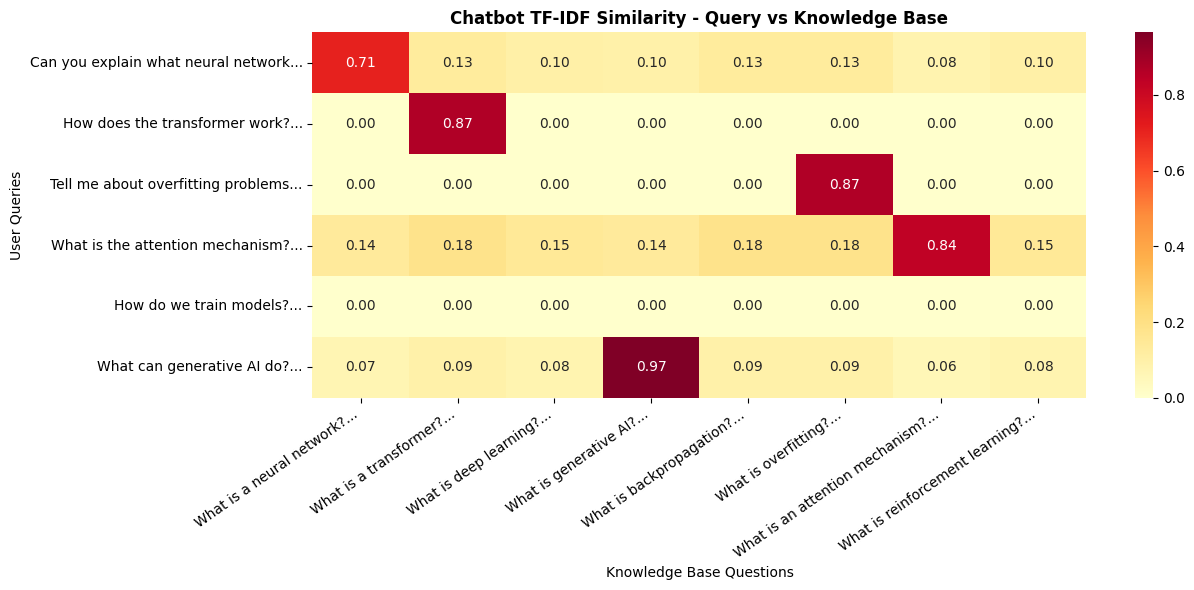

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── Build a retrieval-based QA chatbot ────────────────────────────────────────
knowledge_base = {
    "What is a neural network?":
        "A neural network is a computational model inspired by the human brain, composed of layers of interconnected nodes (neurons) that learn patterns from data via backpropagation.",
    "What is a transformer?":
        "A transformer is a deep learning architecture based on self-attention mechanisms. It processes entire sequences in parallel and is the foundation for large language models like BERT and GPT.",
    "What is deep learning?":
        "Deep learning is a subset of machine learning using multi-layered neural networks to automatically learn hierarchical feature representations from raw data.",
    "What is generative AI?":
        "Generative AI refers to AI systems that can create new content (text, images, code, music) by learning the statistical distribution of training data.",
    "What is backpropagation?":
        "Backpropagation is the algorithm for training neural networks. It computes gradients of the loss with respect to each weight using the chain rule, then updates weights via gradient descent.",
    "What is overfitting?":
        "Overfitting occurs when a model learns the training data too well, including noise, causing poor generalization to unseen data. It is mitigated by dropout, regularization, and more data.",
    "What is an attention mechanism?":
        "An attention mechanism allows a model to selectively focus on different parts of the input when producing each output element, enabling capture of long-range dependencies.",
    "What is reinforcement learning?":
        "Reinforcement learning is a paradigm where an agent learns to take actions in an environment to maximize cumulative reward through trial and error.",
}

questions = list(knowledge_base.keys())
answers   = list(knowledge_base.values())

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(questions)

def chat(user_input, threshold=0.25):
    vec = vectorizer.transform([user_input])
    sims = cosine_similarity(vec, tfidf_matrix)[0]
    best_idx  = np.argmax(sims)
    best_score = sims[best_idx]
    if best_score < threshold:
        return "I don't have information on that topic yet.", best_score
    return answers[best_idx], best_score

# Demo conversation
test_queries = [
    "Can you explain what neural networks are?",
    "How does the transformer work?",
    "Tell me about overfitting problems",
    "What is the attention mechanism?",
    "How do we train models?",
    "What can generative AI do?",
]
rows_chat = []
for q in test_queries:
    response, score = chat(q)
    rows_chat.append({'User Query': q, 'Confidence': f'{score:.3f}',
                       'Bot Response': response[:80]+'...'})
df_chat = pd.DataFrame(rows_chat)
print("=== Retrieval-Based Chatbot Demo ===")
print(df_chat.to_string(index=False))

# Similarity heatmap
all_inputs = test_queries + questions
all_vecs   = vectorizer.transform(all_inputs)
sim_matrix = cosine_similarity(all_vecs[:len(test_queries)], all_vecs[len(test_queries):])
fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[q[:35]+'...' for q in questions],
            yticklabels=[q[:35]+'...' for q in test_queries], ax=ax)
ax.set_title('Chatbot TF-IDF Similarity - Query vs Knowledge Base', fontweight='bold')
ax.set_xlabel('Knowledge Base Questions'); ax.set_ylabel('User Queries')
plt.xticks(rotation=35, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/05_chatbot_similarity.png', dpi=130, bbox_inches='tight'); plt.show()

---
## Module 6 - Summary & AI Universe Coding Recap


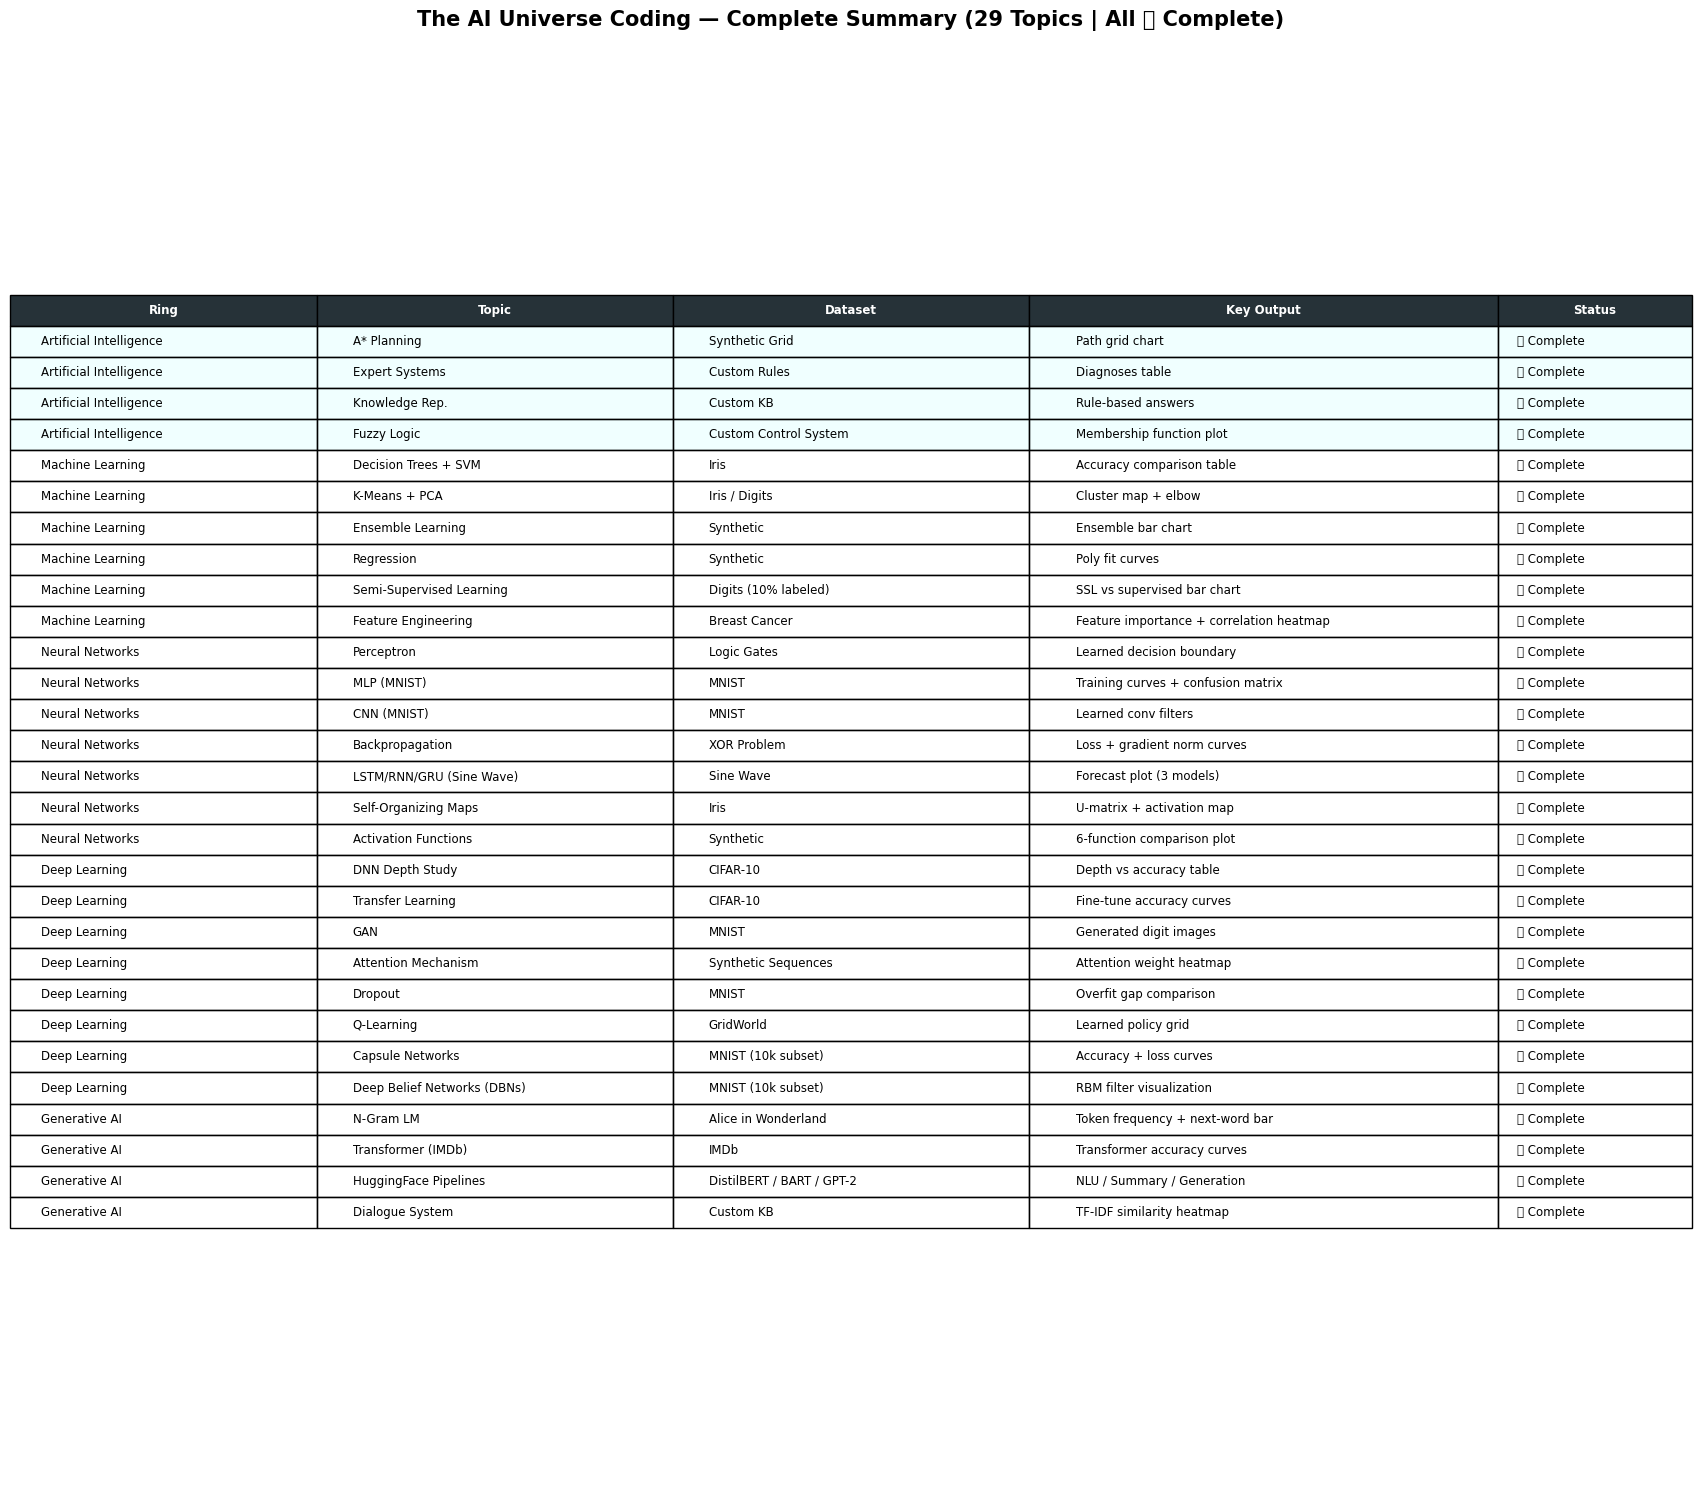

✅ Completed demos : 29
📊 Total topics    : 29

Ring breakdown:
Ring
Deep Learning              8
Neural Networks            7
Machine Learning           6
Artificial Intelligence    4
Generative AI              4

✅ All outputs saved to: /content/drive/MyDrive/AI_Universe_Course


In [42]:
# ── Full summary table ─────────────────────────────────────────────────
summary_data = {
    'Ring': [
        'Artificial Intelligence','Artificial Intelligence','Artificial Intelligence',
        'Artificial Intelligence',
        'Machine Learning','Machine Learning','Machine Learning','Machine Learning',
        'Machine Learning','Machine Learning',
        'Neural Networks','Neural Networks','Neural Networks','Neural Networks',
        'Neural Networks','Neural Networks','Neural Networks',
        'Deep Learning','Deep Learning','Deep Learning','Deep Learning',
        'Deep Learning','Deep Learning','Deep Learning','Deep Learning',
        'Generative AI','Generative AI','Generative AI','Generative AI',
    ],
    'Topic': [
        'A* Planning','Expert Systems','Knowledge Rep.','Fuzzy Logic',
        'Decision Trees + SVM','K-Means + PCA','Ensemble Learning','Regression',
        'Semi-Supervised Learning','Feature Engineering',
        'Perceptron','MLP (MNIST)','CNN (MNIST)','Backpropagation',
        'LSTM/RNN/GRU (Sine Wave)','Self-Organizing Maps','Activation Functions',
        'DNN Depth Study','Transfer Learning','GAN','Attention Mechanism',
        'Dropout','Q-Learning','Capsule Networks','Deep Belief Networks (DBNs)',
        'N-Gram LM','Transformer (IMDb)','HuggingFace Pipelines','Dialogue System',
    ],
    'Dataset': [
        'Synthetic Grid','Custom Rules','Custom KB','Custom Control System',
        'Iris','Iris / Digits','Synthetic','Synthetic',
        'Digits (10% labeled)','Breast Cancer',
        'Logic Gates','MNIST','MNIST','XOR Problem',
        'Sine Wave','Iris','Synthetic',
        'CIFAR-10','CIFAR-10','MNIST','Synthetic Sequences',
        'MNIST','GridWorld','MNIST (10k subset)','MNIST (10k subset)',
        'Alice in Wonderland','IMDb','DistilBERT / BART / GPT-2','Custom KB',
    ],
    'Key Output': [
        'Path grid chart','Diagnoses table','Rule-based answers','Membership function plot',
        'Accuracy comparison table','Cluster map + elbow','Ensemble bar chart','Poly fit curves',
        'SSL vs supervised bar chart','Feature importance + correlation heatmap',
        'Learned decision boundary','Training curves + confusion matrix','Learned conv filters','Loss + gradient norm curves',
        'Forecast plot (3 models)','U-matrix + activation map','6-function comparison plot',
        'Depth vs accuracy table','Fine-tune accuracy curves','Generated digit images','Attention weight heatmap',
        'Overfit gap comparison','Learned policy grid','Accuracy + loss curves','RBM filter visualization',
        'Token frequency + next-word bar','Transformer accuracy curves','NLU / Summary / Generation','TF-IDF similarity heatmap',
    ],
    'Status': ['✅ Complete'] * 29,
}
df_summary = pd.DataFrame(summary_data)

# ── Color map ─────────────────────────────────────────────────────────────────
ring_colors = {
    'Artificial Intelligence': '#4fc3f7',
    'Machine Learning':         '#a5d6a7',
    'Neural Networks':          '#ce93d8',
    'Deep Learning':            '#ef9a9a',
    'Generative AI':            '#ffe082',
}

fig, ax = plt.subplots(figsize=(17, 15))
ax.axis('off')
table = ax.table(cellText=df_summary.values, colLabels=df_summary.columns,
                 cellLoc='left', loc='center',
                 colWidths=[0.19, 0.22, 0.22, 0.29, 0.12])
table.auto_set_font_size(False); table.set_fontsize(8.5); table.scale(1, 1.5)

import matplotlib.colors as mc
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#263238')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        ring  = df_summary.iloc[row-1]['Ring']
        base  = mc.to_rgba(ring_colors[ring])
        light = tuple([min(1, v+0.55) for v in base[:3]] + [0.4])
        cell.set_facecolor(light)

ax.set_title('The AI Universe Coding — Complete Summary (29 Topics | All ✅ Complete)',
             fontsize=15, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/06_course_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Stats printout ────────────────────────────────────────────────────────────
print(f"✅ Completed demos : {len(df_summary)}")
print(f"📊 Total topics    : {len(df_summary)}")
print(f"\nRing breakdown:\n{df_summary['Ring'].value_counts().to_string()}")
print(f"\n✅ All outputs saved to: {SAVE_DIR}")

---
## Congratulations - You have completed *The AI Universe Coding* !

### What you built and ran:

| Ring | Demos | Key Skills |
|------|-------|------------|
| Artificial Intelligence | BFS/A*, Expert System | Search, Rule-based reasoning |
| Machine Learning | 6 classifiers, K-Means, PCA, Ensemble, Regression | Scikit-learn, model comparison |
| Neural Networks | Perceptron, MLP, CNN, LSTM, RNN, SOM | Keras, backprop, sequence modeling |
| Deep Learning | DNN depth study, Transfer Learning, GAN, Attention, Dropout, Q-Learning | Fine-tuning, generative models, RL |
| Generative AI | N-Gram LM, Transformer from scratch, HuggingFace NLU/Summarization/Generation, Chatbot | Transformers, LLMs, dialogue |

### Next Steps
- Read: *Attention Is All You Need* (Vaswani et al., 2017)
- Explore: [HuggingFace Model Hub](https://huggingface.co/models)
- Practice: [Kaggle competitions](https://www.kaggle.com)
- Specialize: Adversarial ML, Federated Learning, Quantum AI
